# Hotel Booking Cancellation Prediction — Combined Team Notebook


Dataset: [Hotel Booking Demand (Kaggle)](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand/data) ·
GitHub repo: [eddy-cho26/hotel_cancellation_model_207](https://github.com/eddy-cho26/hotel_cancellation_model_207)



| Part | Source notebook | Contributor |
|---|---|---|
| 0 | Setting Up Path | Akim Jordan Williams |
| 1 | `end_to_end.ipynb` | Sarankan Thirunavukkarasu, Edward Cho, Akim Jordan Williams, Oliver Silen |
| 2 | `feature_prep.ipynb` | Edward Cho, Sarankan Thirunavukkarasu |
| 3 | `logistic_regression.ipynb` | Akim Jordan Williams |
| 4 | `decision_tree.ipynb` | Oliver Silen |
| 5 | `random_forest.ipynb` | Sarankan Thirunavukkarasu |
| 6 | `cnn_model.ipynb` | Edward Cho |
| 7 | Subgroup Performance Evaluation | Akim Jordan Williams |




---

## Part 0 — Setting Up Path

> **Contributor: Akim Jordan Williams** (`akim_williams@berkeley.edu`)


In [1]:
from pathlib import Path

# The kernel starts in notebooks/ under Jupyter but at the project root under VS Code.
ROOT = Path("..") if Path("../data").is_dir() else Path(".")

RAW_DIR = (ROOT / "data/raw").as_posix()
PROCESSED_DIR = (ROOT / "data/processed").as_posix()
Path(PROCESSED_DIR).mkdir(parents=True, exist_ok=True)

print("RAW_DIR      :", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)

RAW_DIR      : ../data/raw
PROCESSED_DIR: ../data/processed


*End of Part 0 — combined-notebook setup (Akim Jordan Williams).*

---

## Part 1 — Data Cleaning, Feature Engineering & Exploratory Data Analysis

> **Source notebook:** [`end_to_end.ipynb`](https://github.com/eddy-cho26/hotel_cancellation_model_207/blob/main/notebooks/end_to_end.ipynb) — the shared team notebook.
>
> **Inputs:** `data/raw/hotel_bookings.csv` ·
> **Outputs:** `processed_data.csv`, `processed_data_train.csv`, `processed_data_test.csv`


Ownership within this part, as recorded in the project report:

| Portion of Part 1 | Contributor |
|---|---|
| Sections 0–8: loading, cleaning, feature engineering, leakage removal, train/test split, outlier handling, log transforms, encoding, saving processed data | **Sarankan Thirunavukkarasu** (`sarankant@berkeley.edu`) |
| EDA sections 1–6: target balance, distributions and skew, feature-vs-target relationships, correlation analysis, time-based patterns, mutual information | **Edward Cho** (`eddycho@berkeley.edu`) |
| EDA section 7: `deposit_type_Non Refund` leakage deep dive | **Edward Cho** (`eddycho@berkeley.edu`) |
| Every figure in this part, and the written interpretation underneath each figure | **Akim Jordan Williams** (`akim_williams@berkeley.edu`) |

### Hotel Cancellation — End-to-End Notebook

This notebook combines the three project notebooks: `data-processing.ipynb` -> `eda.ipynb` -> `visualization.ipynb`.

It runs end-to-end from the raw CSV: clean & engineer features, split into train/test early, then run all exploratory analysis and figures.

Anything that becomes a decision (transforms, feature-selections, or outliers) is computed on the training split only. Structural facts with no decision baked in (shape, columns, dtypes, raw missing-value counts, overall target class balance) are shown on the full data. If a val/test row could influence a modeling call, it is treated as leaked.

#### 0. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
print("Done Importing")

Done Importing


#### 1. Load Raw Data



In [3]:
df = pd.read_csv(f"{RAW_DIR}/hotel_bookings.csv")
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


#### 2. Structural Overview (full data, no split yet)


In [4]:
# Structural facts on the raw data 
print(f"Data shape: {df.shape}")
print("\nColumn names:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nUnique value count per column:\n", df.nunique())
print("\nN/A's per column:\n", df.isna().sum())

Data shape: (119390, 32)

Column names: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Dtypes:
 hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             i

#### 3. Data Cleaning & Feature Engineering


In [5]:
# Handle missing values
df["children"] = df["children"].fillna(0).astype(int)
df["country"] = df["country"].fillna("N/A")

# Keep only bookings with at least one guest
total_guests = df["adults"] + df["children"] + df["babies"]
df = df[total_guests > 0].copy()

# Engineered features
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["room_mismatch"] = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)

# Drop leakage / unused / high-cardinality columns
df = df.drop(columns=["agent", "reserved_room_type", "assigned_room_type", "company",
                      "meal", "market_segment", "reservation_status", "reservation_status_date"])

df["total_guests"] = df["adults"] + df["children"] + df["babies"]
print(f"Data shape after cleaning: {df.shape}")

Data shape after cleaning: (119210, 27)


#### 4. Train / Test Split

We split here, before all EDA. From this point on, every decision is made from `train_df` only.


In [6]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["is_canceled"]
)
print(f"Train shape: {train_df.shape}   Test shape: {test_df.shape}")

Train shape: (95368, 27)   Test shape: (23842, 27)


#### 5. Outlier Handling (decided on train)

The `adr < 5000` cutoff is chosen from the train distribution and then applied identically to test as a fixed rule. 


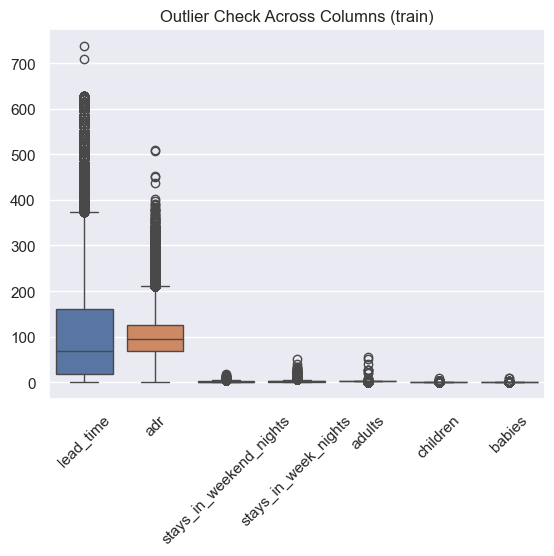

Train shape: (95368, 27)   Test shape: (23841, 27)


In [7]:
numerical_cols = ["lead_time", "adr", "stays_in_weekend_nights", "stays_in_week_nights",
                  "adults", "children", "babies"]
sns.boxplot(train_df[numerical_cols])
plt.title("Outlier Check Across Columns (train)")
plt.xticks(rotation=45)
plt.show()

# One extreme adr outlier exists; apply the same threshold to both splits.
train_df = train_df[train_df["adr"] < 5000].copy()
test_df = test_df[test_df["adr"] < 5000].copy()
print(f"Train shape: {train_df.shape}   Test shape: {test_df.shape}")

#### 6. Log Transforms

The skew check that motivates these logs is in the EDA section below (train only). The transform itself is deterministic per row (no fitting), so it is applied to both splits.


In [8]:
for frame in (train_df, test_df):
    frame["lead_time_log"] = np.log1p(frame["lead_time"])
    frame["adr_log"] = np.log1p(frame["adr"])

c:\Users\akimj\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


#### 7. Encoding

Any data-driven encoder is fit on train and applied to test. Country frequency encoding uses train frequencies only (unseen test countries map to 0), and test one-hot columns are realigned to the train column set.


In [9]:
one_hot_targets = ["deposit_type", "customer_type", "distribution_channel", "arrival_date_month"]

# hotel to binary
train_df["hotel"] = train_df["hotel"].map({"City Hotel": 1, "Resort Hotel": 0})
test_df["hotel"] = test_df["hotel"].map({"City Hotel": 1, "Resort Hotel": 0})

# Frequency-encode country using TRAIN frequencies only; unseen test countries to 0
country_frequencies = train_df["country"].value_counts(normalize=True)
train_df["country_encoded"] = train_df["country"].map(country_frequencies)
test_df["country_encoded"] = test_df["country"].map(country_frequencies).fillna(0.0)
train_df = train_df.drop(columns=["country"])
test_df = test_df.drop(columns=["country"])

# One-hot encode, then align test columns to the train column set
train_df = pd.get_dummies(train_df, columns=one_hot_targets, drop_first=True, dtype=int)
test_df = pd.get_dummies(test_df, columns=one_hot_targets, drop_first=True, dtype=int)
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

train_df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September
32983,0,0,11,2017,6,10,0,2,2,0,...,0,1,0,0,0,0,0,0,0,0
54151,1,1,128,2016,28,7,0,3,2,0,...,0,0,0,1,0,0,0,0,0,0
76714,1,0,7,2016,51,14,0,2,1,0,...,1,0,0,0,0,0,0,0,0,0
2274,0,1,77,2015,41,8,0,3,2,2,...,0,0,0,0,0,0,0,0,1,0
15050,0,0,6,2016,29,13,0,1,1,0,...,0,0,0,1,0,0,0,0,0,0


#### 8. Save Processed Data

In [10]:
# full = train + test reassembled in original row order (kept for compatibility)
full_df = pd.concat([train_df, test_df]).sort_index()
full_df.to_csv(f"{PROCESSED_DIR}/processed_data.csv", index=False)
train_df.to_csv(f"{PROCESSED_DIR}/processed_data_train.csv", index=False)
test_df.to_csv(f"{PROCESSED_DIR}/processed_data_test.csv", index=False)
print("Saved processed full / train / test CSVs")

Saved processed full / train / test CSVs


### Exploratory Data Analysis & Visualization

#### Goal

Understand the structure, distributions, and predictive signal in the booking data before modeling, pairing each finding with the figure that communicates it.

Everything below runs on `train_df` only: every output feeds a transform, feature-selection, or outlier decision, so it must not see val/test rows. The one exception is the target class-balance figure, a purely structural fact shown on the full data.


In [11]:
# EDA + visualization setup
df = train_df.copy()

# onehot encoding function
def from_onehot(frame, prefix, baseline):
    s = pd.Series(baseline, index=frame.index)
    for c in [c for c in frame.columns if c.startswith(prefix)]:
        s = s.mask(frame[c] == 1, c[len(prefix):])
    return s

# mapping and transforming variables
df["hotel_label"] = df["hotel"].map({1: "City Hotel", 0: "Resort Hotel"})
df["deposit_type"] = from_onehot(df, "deposit_type_", "No Deposit")
df["customer_type"] = from_onehot(df, "customer_type_", "Contract")
df["distribution_channel"] = from_onehot(df, "distribution_channel_", "Corporate")
df["repeated_guest"] = df["is_repeated_guest"].map({0: "No", 1: "Yes"})
df["arrival_month"] = from_onehot(df, "arrival_date_month_", "April")

categorical_cols = ["hotel_label", "deposit_type", "customer_type",
                    "distribution_channel", "repeated_guest"]

overall_rate = df["is_canceled"].mean()
print(f"Train rows: {len(df):,}   Train cancellation rate: {overall_rate:.1%}")

Train rows: 95,368   Train cancellation rate: 37.1%


#### 1. Target Variable Balance

Check how (im)balanced the target is. This drives the evaluation choices later (ROC-AUC / PR-AUC over raw accuracy).

Shown on the full data: class balance is a structural fact, not a decision derived from train.

Stayed (0): 62.9 %
Cancelled (1): 37.1 %


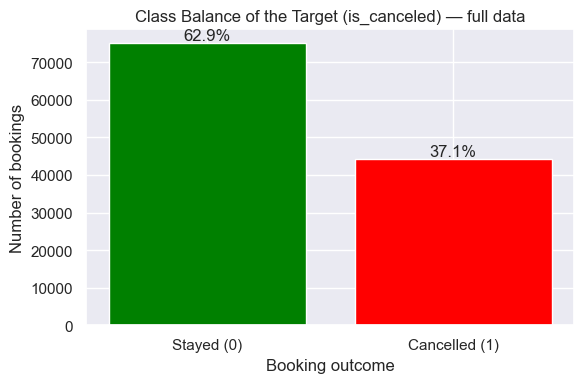

In [12]:
# class balance 
counts = full_df["is_canceled"].value_counts().sort_index()

pct = counts / len(full_df) * 100
print("Stayed (0):", round(pct[0], 1), "%")
print("Cancelled (1):", round(pct[1], 1), "%")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Stayed (0)", "Cancelled (1)"], counts.values, color=["green", "red"])
ax.text(0, counts.values[0], f"{pct[0]:.1f}%", ha="center", va="bottom")
ax.text(1, counts.values[1], f"{pct[1]:.1f}%", ha="center", va="bottom")
ax.set_title("Class Balance of the Target (is_canceled) — full data")
ax.set_xlabel("Booking outcome")
ax.set_ylabel("Number of bookings")
plt.tight_layout()
plt.show()

The figure above shows the split between bookings that were kept and those that were cancelled. Around 37% of the bookings were cancelled, so the classes are somewhat imbalanced but not severely. The cancelled bookings are the ones we actually care about predicting, so accuracy is a misleading metric here: a model that just guesses "not cancelled" every time would already hit about 63%. Because of that I'll focus on ROC-AUC and PR-AUC, which look at how well the model ranks the minority class rather than just how many it gets right overall.

#### 2. Distribution Analysis (patterns & skewness)

Examine how the key features are distributed to spot skew, long tails, and dominant categories. This is what motivates the log transforms applied earlier.

In [13]:
num_cols = [
    "lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights",
    "previous_cancellations", "booking_changes", "total_of_special_requests", "days_in_waiting_list",
]

print("Numeric feature summary:\n")
print(df[num_cols].describe().round(2).to_string())
print("\nSkewness (high positive = right-skewed):")
print(df[num_cols].skew().round(2).sort_values(ascending=False).to_string())

Numeric feature summary:

       lead_time       adr  stays_in_week_nights  stays_in_weekend_nights  previous_cancellations  booking_changes  total_of_special_requests  days_in_waiting_list
count   95368.00  95368.00              95368.00                 95368.00                95368.00         95368.00                   95368.00              95368.00
mean      104.03    101.85                  2.50                     0.93                    0.09             0.22                       0.57                  2.33
std       106.75     47.94                  1.89                     0.99                    0.83             0.64                       0.79                 17.59
min         0.00      0.00                  0.00                     0.00                    0.00             0.00                       0.00                  0.00
25%        18.00     69.56                  1.00                     0.00                    0.00             0.00                       0.00             

In [14]:
print("Categorical feature counts (sorted by frequency):\n")
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts().to_string())
    print()

Categorical feature counts (sorted by frequency):

--- hotel_label ---
hotel_label
City Hotel      63433
Resort Hotel    31935

--- deposit_type ---
deposit_type
No Deposit    83567
Non Refund    11669
Refundable      132

--- customer_type ---
customer_type
Transient          71625
Transient-Party    20059
Contract            3236
Group                448

--- distribution_channel ---
distribution_channel
TA/TO        78260
Direct       11684
Corporate     5265
GDS            155
Undefined        4

--- repeated_guest ---
repeated_guest
No     92347
Yes     3021



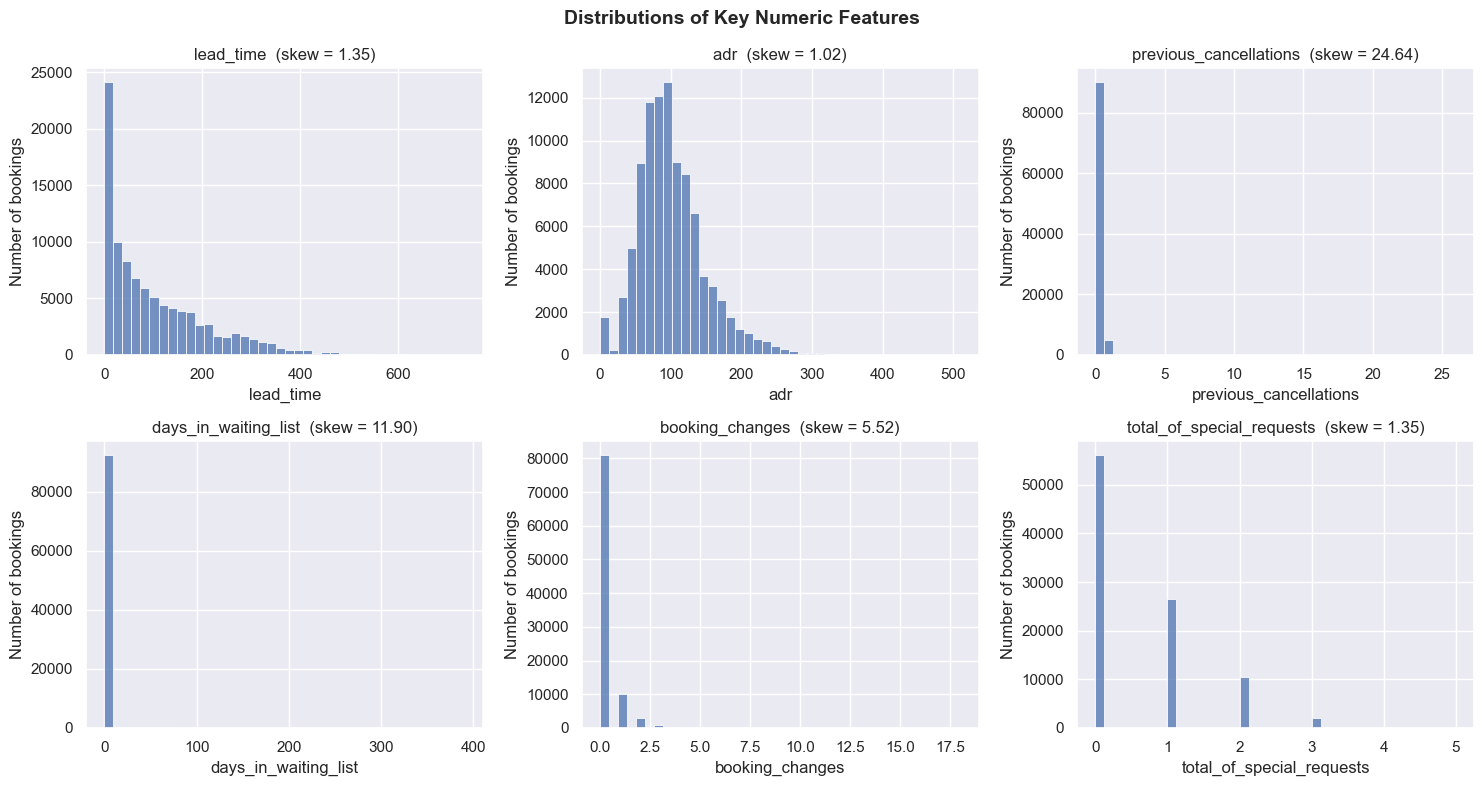

In [15]:
# histograms of the key numeric features
dist_cols = ["lead_time", "adr", "previous_cancellations",
             "days_in_waiting_list", "booking_changes", "total_of_special_requests"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), dist_cols):
    sns.histplot(df[col], bins=40,  ax=ax)
    ax.set_title(f"{col}  (skew = {df[col].skew():.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of bookings")

fig.suptitle("Distributions of Key Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

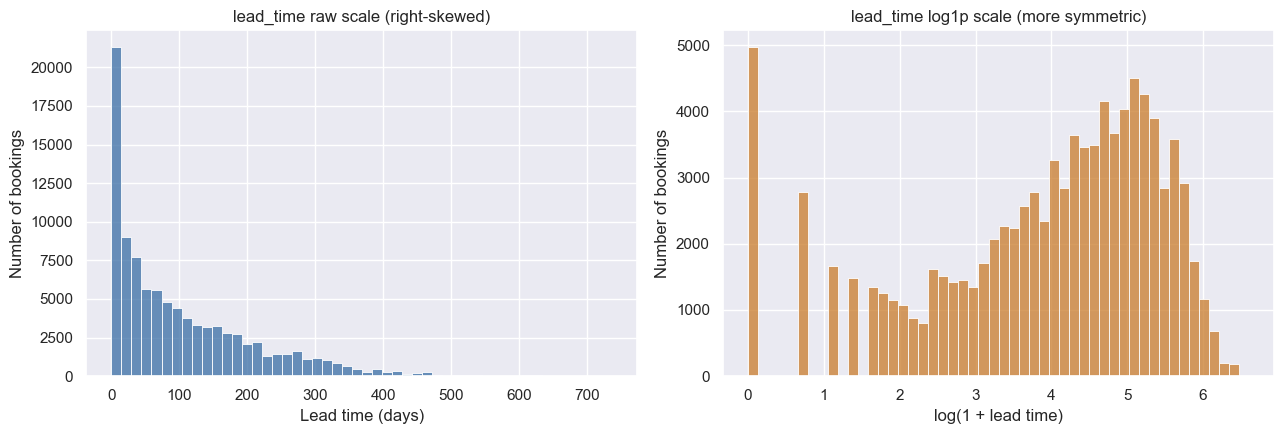

In [16]:
# lead_time is strongly right-skewed. Compare raw vs log scale
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["lead_time"], bins=50, color="#3A6EA5", ax=axes[0])
axes[0].set_title("lead_time raw scale (right-skewed)")
axes[0].set_xlabel("Lead time (days)")
axes[0].set_ylabel("Number of bookings")

sns.histplot(df["lead_time_log"], bins=50, color="#C97B2B", ax=axes[1])
axes[1].set_title("lead_time log1p scale (more symmetric)")
axes[1].set_xlabel("log(1 + lead time)")
axes[1].set_ylabel("Number of bookings")

plt.tight_layout()
plt.show()

The summary and figures above show each key numeric feature's distribution, plus a raw-vs-log comparison for lead_time. The numeric features are mostly right-skewed. `previous_cancellations`, `days_in_waiting_list`, and `booking_changes` are zero for almost every booking with a few rare large values, while lead_time and adr are continuous but have long right tails which is why lead_time and adr get the log1p transforms.

#### 3. Feature vs. Target Relationships

How each feature relates to `is_canceled`: per-category cancellation rates against the overall baseline, and the lead-time signal.

In [17]:
print(f"Cancellation rate by category (overall = {overall_rate:.1%})\n")
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df.groupby(col)["is_canceled"].mean().sort_values(ascending=False).round(3).to_string())
    print()

Cancellation rate by category (overall = 37.1%)

--- hotel_label ---
hotel_label
City Hotel      0.416
Resort Hotel    0.280

--- deposit_type ---
deposit_type
Non Refund    0.993
No Deposit    0.284
Refundable    0.212

--- customer_type ---
customer_type
Transient          0.408
Contract           0.312
Transient-Party    0.254
Group              0.098

--- distribution_channel ---
distribution_channel
Undefined    0.750
TA/TO        0.410
Corporate    0.223
GDS          0.194
Direct       0.177

--- repeated_guest ---
repeated_guest
No     0.378
Yes    0.147



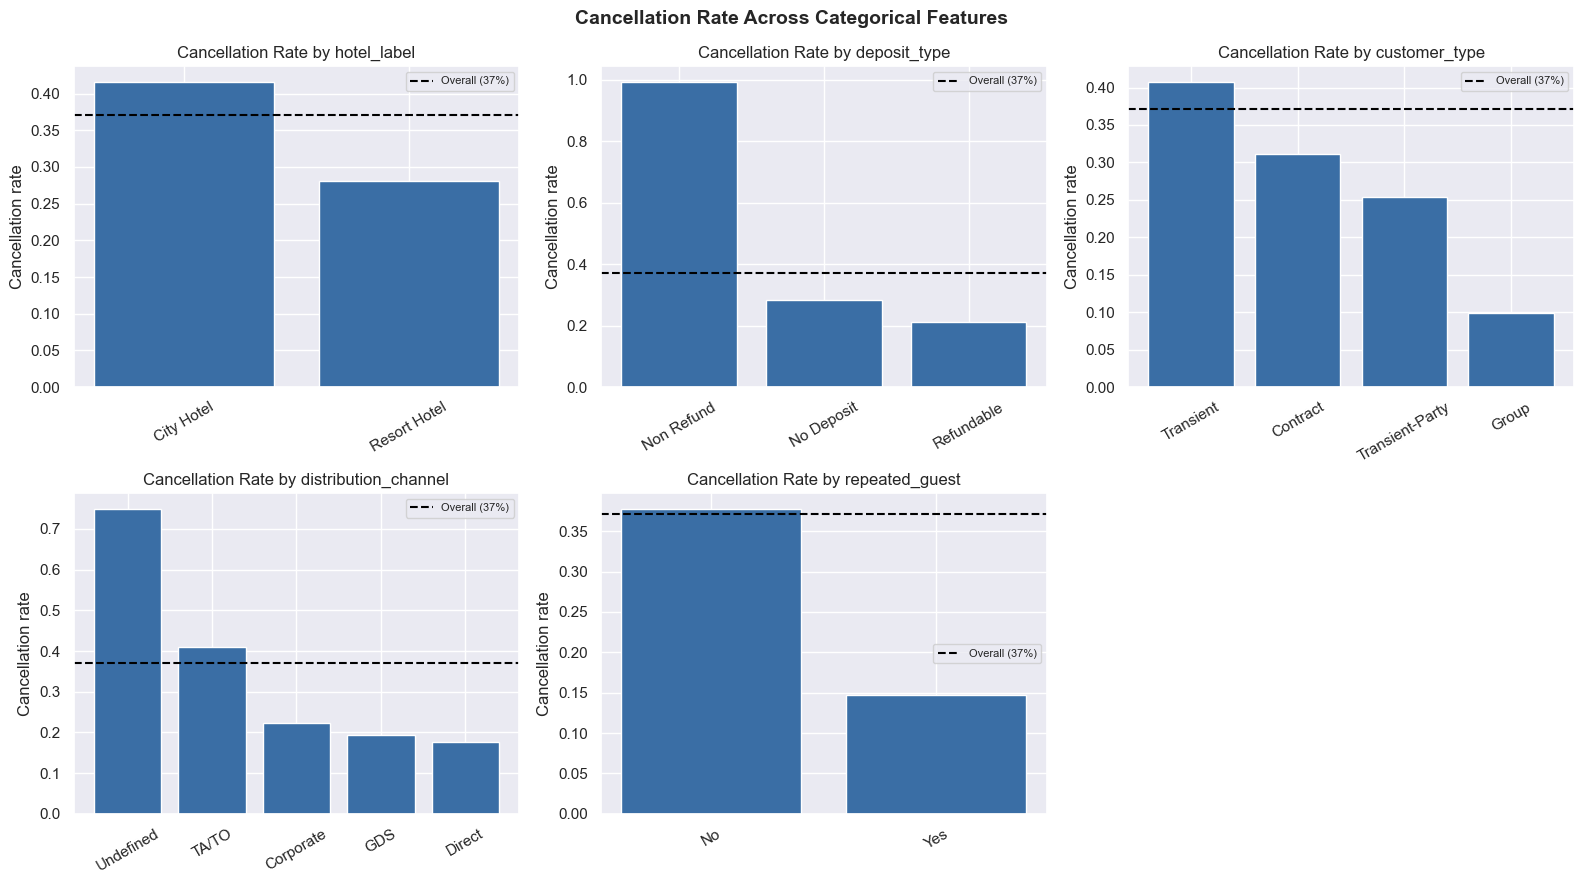

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, col in zip(axes, categorical_cols):
    rate = df.groupby(col)["is_canceled"].mean().sort_values(ascending=False)
    ax.bar(rate.index.astype(str), rate.values, color="#3A6EA5")
    ax.axhline(overall_rate, color="black", linestyle="--",
               label=f"Overall ({overall_rate:.0%})")
    ax.set_title(f"Cancellation Rate by {col}")
    ax.set_ylabel("Cancellation rate")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

axes[-1].axis("off")  # hide the unused 6th panel
fig.suptitle("Cancellation Rate Across Categorical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

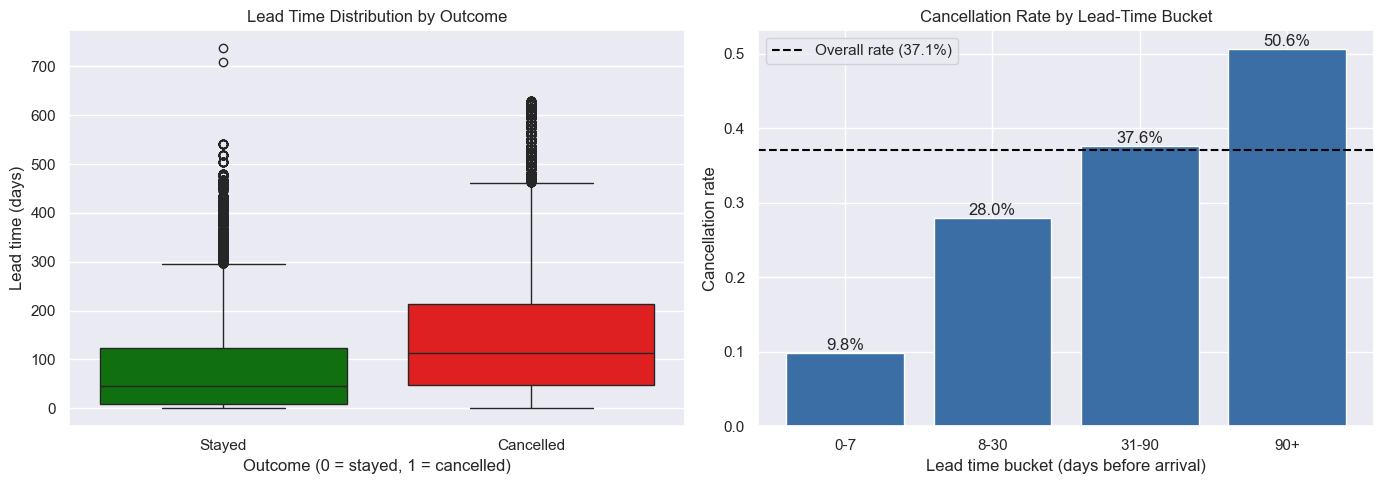

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="is_canceled", y="lead_time",
            hue="is_canceled", palette={0: "green", 1: "red"}, legend=False, ax=axes[0])
axes[0].set_title("Lead Time Distribution by Outcome")
axes[0].set_xlabel("Outcome (0 = stayed, 1 = cancelled)")
axes[0].set_ylabel("Lead time (days)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Stayed", "Cancelled"])

bins = [-1, 7, 30, 90, np.inf]
labels = ["0-7", "8-30", "31-90", "90+"]
bucket_rate = df.groupby(pd.cut(df["lead_time"], bins=bins, labels=labels),
                         observed=True)["is_canceled"].mean()
bars = axes[1].bar(bucket_rate.index.astype(str), bucket_rate.values, color="#3A6EA5")
for b, v in zip(bars, bucket_rate.values):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f"{v:.1%}", ha="center", va="bottom")
axes[1].axhline(overall_rate, color="black", linestyle="--",
                label=f"Overall rate ({overall_rate:.1%})")
axes[1].set_title("Cancellation Rate by Lead-Time Bucket")
axes[1].set_xlabel("Lead time bucket (days before arrival)")
axes[1].set_ylabel("Cancellation rate")
axes[1].legend()

plt.tight_layout()
plt.show()

Lead time is the strongest numeric predictor: cancelled bookings have a higher median lead time, and risk increases monotonically from ~10% for last-minute bookings (0–7 days) to over 50% for bookings made 90+ days out. This is a reliable early risk signal available the moment a booking is made.

Across the categorical features, the most surprising result is that non-refundable deposits cancel about 99% of the time. This is analyzed deeper in section 7.

Furthermore, City Hotels cancel more than Resort Hotels, Transient customers more than Groups, TA/TO channel more than Direct, and repeat guests cancel far less than first-timers. The `distribution_channel` panel also shows a tiny `Undefined` level cancelling very high, but it covers only a handful of bookings with a missing channel, so I treat it as a low-volume data-quality artifact rather than a trustworthy signal.

#### 4. Correlation Analysis

How numeric features relate to the target and to each other. The heatmap is annotated with the exact Pearson values, the ranked bar chart shows the top features by absolute correlation with the target, and the scatter contrasts the two main continuous features.

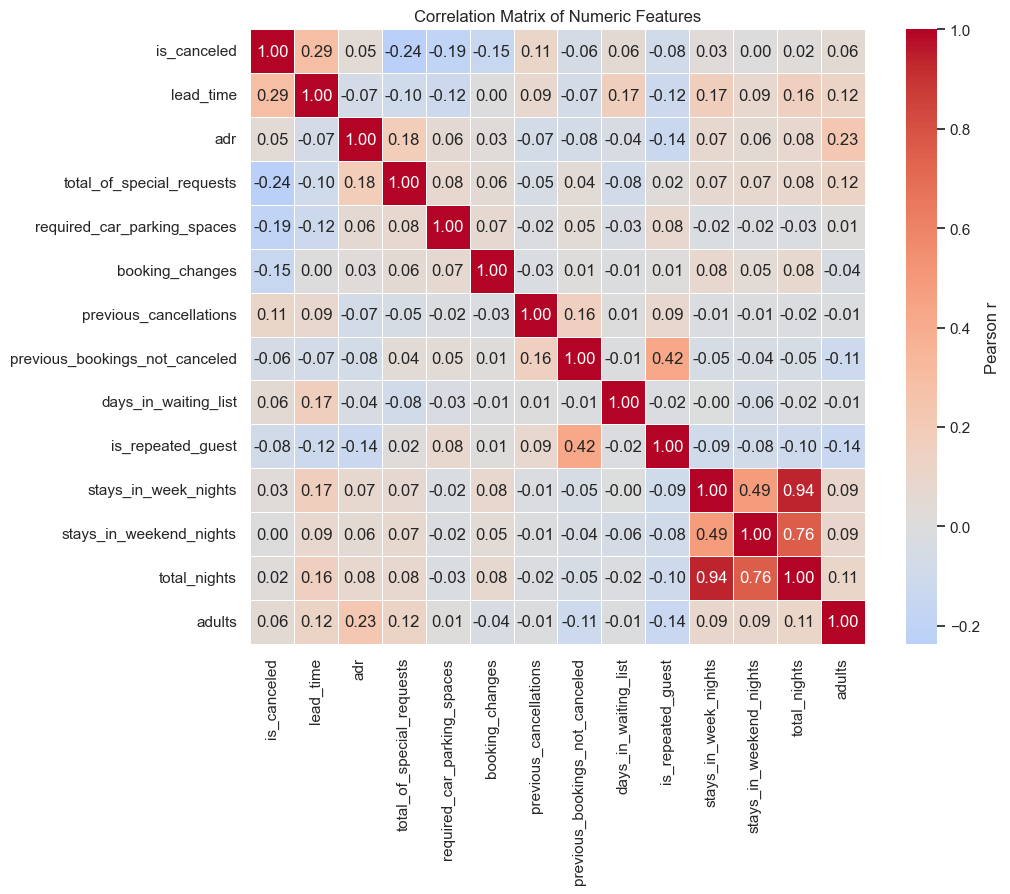

In [20]:
heat_cols = [
    "is_canceled", "lead_time", "adr", "total_of_special_requests",
    "required_car_parking_spaces", "booking_changes", "previous_cancellations",
    "previous_bookings_not_canceled", "days_in_waiting_list", "is_repeated_guest",
    "stays_in_week_nights", "stays_in_weekend_nights", "total_nights", "adults",
]
corr = df[heat_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

Top 15 features by |correlation| with is_canceled:

deposit_type_Non Refund           0.481
country_encoded                   0.325
lead_time                         0.293
room_mismatch                    -0.247
total_of_special_requests        -0.236
required_car_parking_spaces      -0.195
distribution_channel_TA/TO        0.174
distribution_channel_Direct      -0.150
booking_changes                  -0.146
customer_type_Transient           0.133
hotel                             0.133
customer_type_Transient-Party    -0.125
previous_cancellations            0.110
is_repeated_guest                -0.084
previous_bookings_not_canceled   -0.057


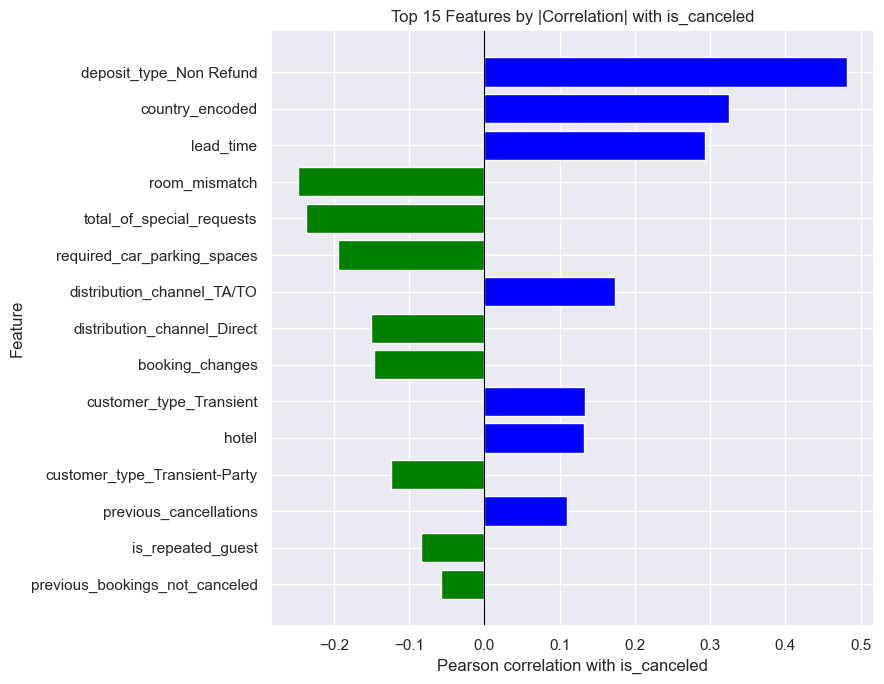

In [21]:
target_corr = (
    df.select_dtypes("number")
      .drop(columns=["is_canceled", "lead_time_log", "adr_log"])
      .corrwith(df["is_canceled"])
)
top = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(15)

print("Top 15 features by |correlation| with is_canceled:\n")
print(top.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["blue" if v > 0 else "green" for v in top.values]
ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 15 Features by |Correlation| with is_canceled")
ax.set_xlabel("Pearson correlation with is_canceled")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

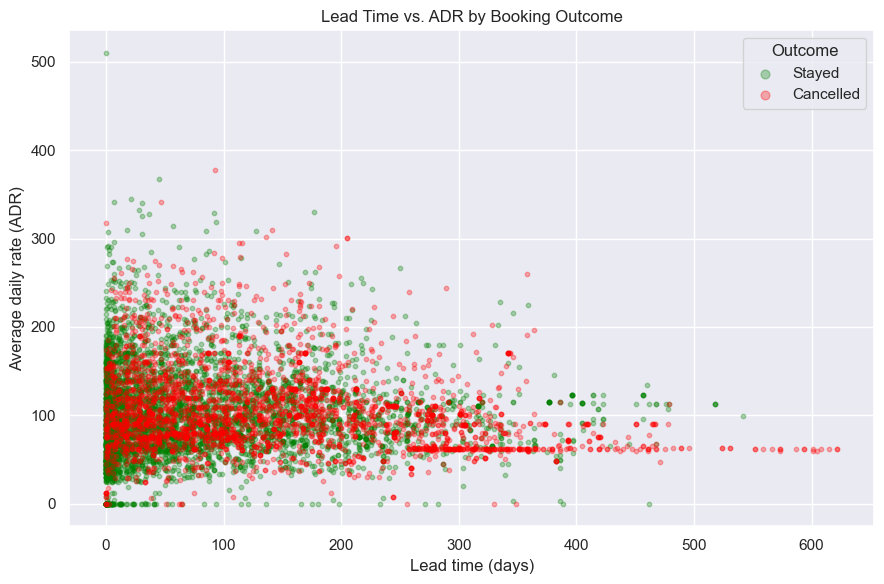

In [22]:
# scatter of the two main continuous features, colored by outcome (sampled to keep the plot readable)
sample = df.sample(n=8000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
for outcome, color, lbl in [(0, "green", "Stayed"), (1, "red", "Cancelled")]:
    sub = sample[sample["is_canceled"] == outcome]
    ax.scatter(sub["lead_time"], sub["adr"], s=10, alpha=0.3,
               color=color, label=lbl)
ax.set_title("Lead Time vs. ADR by Booking Outcome")
ax.set_xlabel("Lead time (days)")
ax.set_ylabel("Average daily rate (ADR)")
ax.legend(title="Outcome", markerscale=2)
plt.tight_layout()
plt.show()

No single numeric feature is collinear enough to be redundant except by construction (`total_nights` = week + weekend nights). Against the target, `deposit_type_Non Refund` (+0.48), `country_encoded` (+0.32) and `lead_time` (+0.29) push risk up. Engagement signals `total_of_special_requests`, `required_car_parking_spaces`, `room_mismatch`, and `booking_changes` pull it down. The red/green split shows risk-raising vs. risk-lowering features at a glance.

The scatter reinforces this: cancelled bookings (red) spread noticeably further to the right along the lead-time axis, while stayed bookings (green) cluster at short lead times. ADR shows no clean vertical separation,  cancellations occur across the full price range, matching its near-zero linear correlation.

#### 5. Time-Based Patterns

Cancellation rate and booking volume by arrival month, in calendar order (`arrival_month` reconstructed from the one-hot columns, April being the dropped baseline).

Cancellation rate by arrival month (overall = 37.1%):

arrival_month
January      0.306
February     0.337
March        0.324
April        0.408
May          0.395
June         0.416
July         0.375
August       0.378
September    0.386
October      0.381
November     0.314
December     0.350


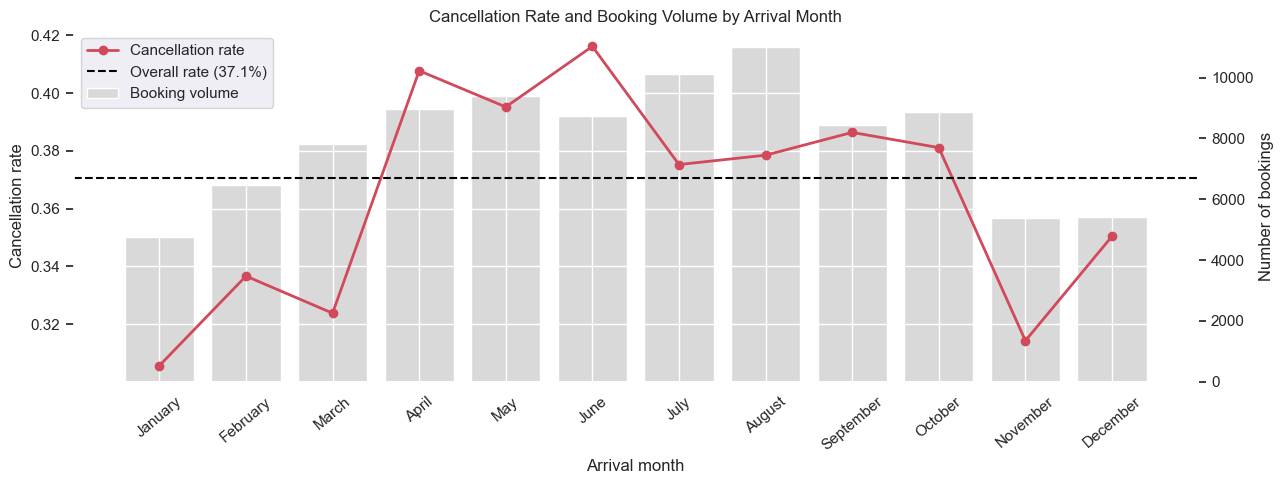

In [23]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
month_rate = df.groupby("arrival_month")["is_canceled"].mean().reindex(month_order)
month_vol = df["arrival_month"].value_counts().reindex(month_order)

print(f"Cancellation rate by arrival month (overall = {overall_rate:.1%}):\n")
print(month_rate.round(3).to_string())

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax2.bar(month_order, month_vol.values, color="#D9D9D9", label="Booking volume")
ax1.plot(month_order, month_rate.values, color="#D1495B", marker="o",
         linewidth=2, label="Cancellation rate")
ax1.axhline(overall_rate, color="black", linestyle="--",
            label=f"Overall rate ({overall_rate:.1%})")

ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)
ax1.set_title("Cancellation Rate and Booking Volume by Arrival Month")
ax1.set_xlabel("Arrival month")
ax1.set_ylabel("Cancellation rate")
ax2.set_ylabel("Number of bookings")
ax1.tick_params(axis="x", rotation=40)

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc="upper left")
plt.tight_layout()
plt.show()

Cancellation rate peaks in spring/early summer (April–June, ~40%) and dips in winter (January, November, ~31%). Booking volume is highest in the busy summer months, so absolute cancellations concentrate there even when the rate is similar. There is a usable seasonal component, though it is weaker than the deposit/lead-time signals.

#### 6. Feature Importance (Mutual Information)

Mutual information captures non-linear dependence between each feature and the target, complementing the linear correlation view above.

Feature importance by mutual information (top 15):

deposit_type_Non Refund        0.1324
lead_time                      0.0810
adr                            0.0774
country_encoded                0.0724
previous_cancellations         0.0433
total_of_special_requests      0.0405
room_mismatch                  0.0402
required_car_parking_spaces    0.0286
distribution_channel_TA/TO     0.0246
booking_changes                0.0203
hotel                          0.0195
customer_type_Transient        0.0175
total_nights                   0.0147
days_in_waiting_list           0.0133
distribution_channel_Direct    0.0108


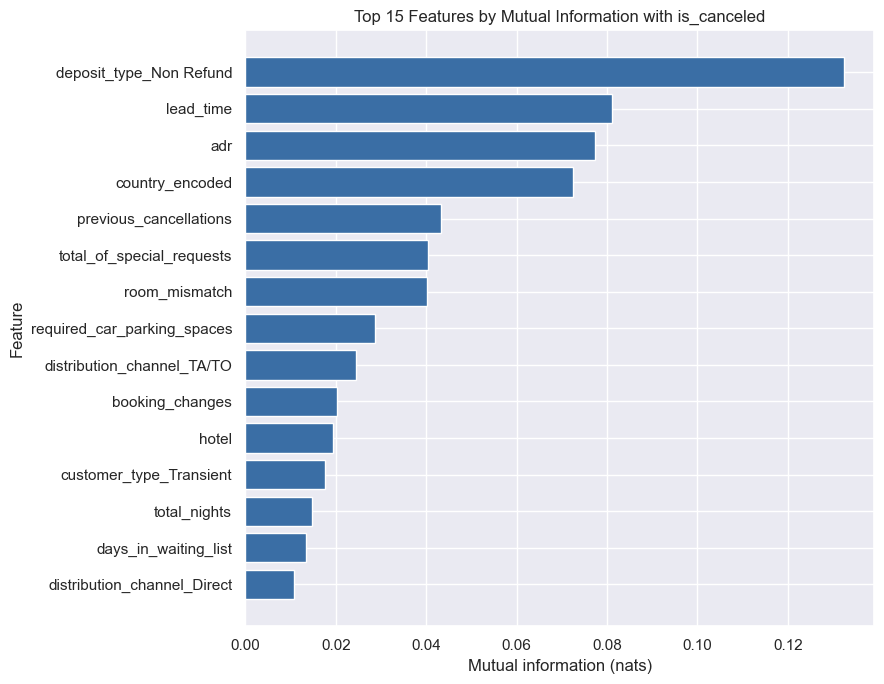

In [24]:
feature_cols = [c for c in df.select_dtypes("number").columns
                if c not in ("is_canceled", "lead_time_log", "adr_log")]
X = df[feature_cols].fillna(0)
y = df["is_canceled"]

mi_scores = mutual_info_classif(X, y, random_state=42)
mi = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print("Feature importance by mutual information (top 15):\n")
print(mi.head(15).round(4).to_string())

mi_top = mi.head(15)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(mi_top.index[::-1], mi_top.values[::-1], color="#3A6EA5")
ax.set_title("Top 15 Features by Mutual Information with is_canceled")
ax.set_xlabel("Mutual information (nats)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

Mutual information agrees with the correlation ranking on the leaders (`deposit_type_Non Refund`, `lead_time`, `adr`, and `country_encoded`) carry the most signal. However, it surfaces `adr` more strongly, hinting at a non-linear price effect that linear correlation understates. These features are the priority inputs for the baseline and boosted models.

#### 7. Deposit-Type Deep Dive (leakage check)

`deposit_type_Non Refund` looks suspicious — it cancels ~99% of the time.

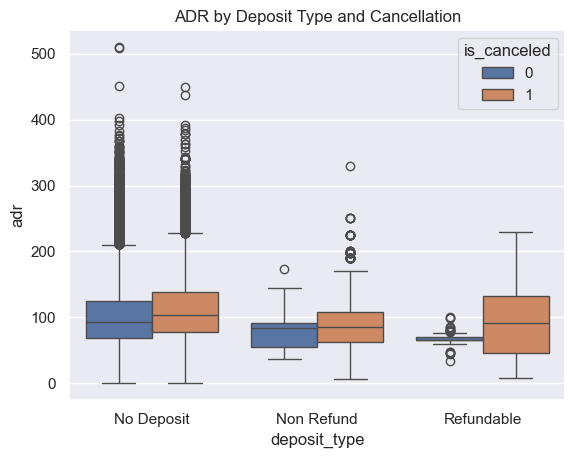

In [25]:
df.groupby(['deposit_type', 'is_canceled'])['adr'].describe()
sns.boxplot(data=df, x='deposit_type', y='adr', hue='is_canceled')
plt.title('ADR by Deposit Type and Cancellation')
plt.show()

In [26]:
# How many samples are in each group?
df.groupby(['deposit_type', 'is_canceled']).size().unstack()

is_canceled,0,1
deposit_type,,
No Deposit,59827,23740
Non Refund,78,11591
Refundable,104,28


In [27]:
df[df['deposit_type'] == 'Non Refund']['distribution_channel'].value_counts(normalize=True)

distribution_channel
TA/TO        0.936413
Corporate    0.036336
Direct       0.027252
Name: proportion, dtype: float64

For the "non refund" deposit type, 93% of cancellations from TA/TO (Travel Agency and Travel Operator like booking.com). The assumption here is that TA/TO's own cancellation policy was reflected.

#### 8. Summary

Baseline cancellation rate: **~37%** (train) is a moderate class imbalance, so models are evaluated with **ROC-AUC / PR-AUC** rather than raw accuracy.

**Strongest risk drivers**
- `deposit_type_Non Refund`: ~99% cancel rate, the single strongest signal (r ≈ 0.48) with a leakage risk (see the deposit deep-dive) so this will be treated with caution.
- `lead_time`: cancel rate climbs from ~10% (0–7 days) to ~51% (90+ days); median lead time ~45 days for stayed vs. ~113 for cancelled.
- `country_encoded`: second-strongest positive predictor (r ≈ 0.32); consider country-level risk tiers.
- `distribution_channel_TA/TO`: travel agent/operator bookings cancel more than Direct.

**Strongest protective signals**
- Engagement lowers risk: `total_of_special_requests` (r ≈ −0.24), `required_car_parking_spaces` (r ≈ −0.20), `booking_changes` (r ≈ −0.15).
- Repeat guests cancel ~15% vs. ~38% for first-timers.

**Other patterns**
- Seasonality: spring/early-summer arrivals cancel most (June ~42%, April ~41%); winter least (January ~30%, November ~31%).
- Skew: most numeric features are right-skewed, which is why `lead_time` and `adr` get log transforms.
- Redundant by construction: `total_nights` = week + weekend nights; `lead_time_log` / `adr_log` duplicate their raw counterparts.


*End of Part 1 — end_to_end.ipynb (Sarankan Thirunavukkarasu, Edward Cho & Akim Jordan Williams).*

---

## Part 2 — Feature Preparation (X/Y Split, NaN Drop, Scaling)

> **Contributor: Edward Cho** (`eddycho@berkeley.edu`)

> **Source notebook:** [`feature_prep.ipynb`](https://github.com/eddy-cho26/hotel_cancellation_model_207/blob/main/notebooks/feature_prep.ipynb) — created by **Edward Cho**, with later updates by **Sarankan Thirunavukkarasu** when the random forest was added.

>
> **Inputs:** `processed_data_train.csv`, `processed_data_test.csv` (Part 1) · **Outputs:** `X_train.csv`, `X_test.csv`, `Y_train.csv`, `Y_test.csv`

### Hotel Cancellation — Feature Prep

Loads the processed train/test splits from `end_to_end.ipynb`, separates features (`X`) from the target (`Y`), carves a stratified validation split out of train, scales `X`'s numeric columns (fit on train only), then saves the resulting `X`/`Y` train/val/test CSVs for use by downstream models.

#### 1. Setup

In [28]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# PROCESSED_DIR is resolved once in Part 0 (was: PROCESSED_DIR = "../data/processed")

#### 2. Load Processed Data

In [29]:
train_df = pd.read_csv(f"{PROCESSED_DIR}/processed_data_train.csv")
test_df = pd.read_csv(f"{PROCESSED_DIR}/processed_data_test.csv")

print(f"Train shape: {train_df.shape}   Test shape: {test_df.shape}")
train_df.head(5)

Train shape: (95368, 45)   Test shape: (23841, 45)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September
0,0,0,11,2017,6,10,0,2,2,0,...,0,1,0,0,0,0,0,0,0,0
1,1,1,128,2016,28,7,0,3,2,0,...,0,0,0,1,0,0,0,0,0,0
2,1,0,7,2016,51,14,0,2,1,0,...,1,0,0,0,0,0,0,0,0,0
3,0,1,77,2015,41,8,0,3,2,2,...,0,0,0,0,0,0,0,0,1,0
4,0,0,6,2016,29,13,0,1,1,0,...,0,0,0,1,0,0,0,0,0,0


#### 3. Split into X / Y

`lead_time` and `adr` are dropped in favor of their log-transformed counterparts (`lead_time_log`, `adr_log`), matching the redundancy call made in the EDA notebook.

In [30]:
drop_cols = ["is_canceled", "lead_time", "adr"]

Y_train = train_df[["is_canceled"]]
Y_test = test_df[["is_canceled"]]


X_train = train_df.drop(columns=drop_cols)
X_test = test_df.drop(columns=drop_cols)

print(f"X_train shape: {X_train.shape}   Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}   Y_test shape: {Y_test.shape}")

X_train shape: (95368, 42)   Y_train shape: (95368, 1)
X_test shape: (23841, 42)   Y_test shape: (23841, 1)


##### Drop rows with missing values

Any row with a `NaN` in its features or target is dropped (train and test independently), rather than imputed.

In [31]:
train_mask = X_train.notna().all(axis=1) & Y_train.notna().all(axis=1)
test_mask = X_test.notna().all(axis=1) & Y_test.notna().all(axis=1)

X_train, Y_train = X_train[train_mask], Y_train[train_mask]
X_test, Y_test = X_test[test_mask], Y_test[test_mask]

print(f"Dropped {(~train_mask).sum()} NaN rows from train, {(~test_mask).sum()} from test")
print(f"X_train shape: {X_train.shape}   Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}   Y_test shape: {Y_test.shape}")

Dropped 0 NaN rows from train, 1 from test
X_train shape: (95368, 42)   Y_train shape: (95368, 1)
X_test shape: (23840, 42)   Y_test shape: (23840, 1)


#### 4. Scale Numeric Features & Save

`StandardScaler` is fit on train only and applied to train, val, and test. Only genuinely continuous/count columns are scaled — binary and one-hot columns (e.g. `hotel`, `deposit_type_*`, `arrival_date_month_*`) are left as 0/1, since standardizing a column with tiny variance (a rare one-hot category) blows up its scaled values. `X`/`Y` for all three splits are saved to CSV after scaling.

In [32]:
binary_cols = [c for c in X_train.columns if X_train[c].nunique() <= 2]
numeric_cols = [c for c in X_train.columns if c not in binary_cols]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"Binary/one-hot columns left unscaled: {len(binary_cols)}")
print(f"Numeric columns scaled: {len(numeric_cols)}")

X_train.to_csv(f"{PROCESSED_DIR}/X_train.csv", index=False)
X_test.to_csv(f"{PROCESSED_DIR}/X_test.csv", index=False)
Y_train.to_csv(f"{PROCESSED_DIR}/Y_train.csv", index=False)
Y_test.to_csv(f"{PROCESSED_DIR}/Y_test.csv", index=False)
print("Saved X/Y train, val, test CSVs (X scaled)")

Binary/one-hot columns left unscaled: 23
Numeric columns scaled: 19
Saved X/Y train, val, test CSVs (X scaled)


*End of Part 2 — feature_prep.ipynb (Edward Cho, updated by Sarankan Thirunavukkarasu).*

---

## Part 3 — Logistic Regression in TensorFlow (Baseline Model)

> **Contributor: Akim Jordan Williams** (`akim_williams@berkeley.edu`)
>
> **Source notebook:** [`logistic_regression.ipynb`](https://github.com/eddy-cho26/hotel_cancellation_model_207/blob/main/notebooks/logistic_regression.ipynb) — authored and maintained solely by **Akim Jordan Williams**.
>
> **Inputs:** `X_train.csv`, `X_test.csv`, `Y_train.csv`, `Y_test.csv` (Part 2) · **Outputs:** validation/test ROC-AUC and PR-AUC, confusion matrix, coefficient plot

### Hotel Cancellation — Logistic Regression

Logistic regression written in TensorFlow (a single sigmoid unit, no hidden layer), trained on the scaled 42-feature split from `feature_prep.ipynb`. This is the interpretable linear model in the project's four-model comparison.

#### 1. Setup

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

# PROCESSED_DIR is resolved once in Part 0 (was: PROCESSED_DIR = "../data/processed")
SEED = 7

tf.keras.utils.set_random_seed(SEED)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


#### 2. Load Data

Already cleaned, encoded, split and scaled by `feature_prep.ipynb`. This notebook does no preprocessing of its own, so every model in the comparison sees identical inputs.

In [34]:
X_train_full = pd.read_csv(f"{PROCESSED_DIR}/X_train.csv")
X_test = pd.read_csv(f"{PROCESSED_DIR}/X_test.csv")
Y_train_full = pd.read_csv(f"{PROCESSED_DIR}/Y_train.csv")["is_canceled"]
Y_test = pd.read_csv(f"{PROCESSED_DIR}/Y_test.csv")["is_canceled"]

print("X_train:", X_train_full.shape, "  X_test:", X_test.shape)
print("Cancel rate  train:", round(Y_train_full.mean(), 4),
      "  test:", round(Y_test.mean(), 4))

X_train: (95368, 42)   X_test: (23840, 42)
Cancel rate  train: 0.3708   test: 0.3708


#### 3. Train / Validation Split

A stratified 80/20 carve-out of the training set for tuning. Test stays untouched until section 6. Class weights offset the 37% / 63% imbalance.

In [35]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_full, Y_train_full, test_size=0.2, random_state=SEED, stratify=Y_train_full)

weights = compute_class_weight("balanced", classes=np.unique(Y_train), y=Y_train)
class_weight = {int(c): w for c, w in zip(np.unique(Y_train), weights)}

print("Train:", X_train.shape, "  Val:", X_val.shape)
print("Class weights:", {k: round(v, 3) for k, v in class_weight.items()})

Train: (76294, 42)   Val: (19074, 42)
Class weights: {0: np.float64(0.795), 1: np.float64(1.349)}


#### 4. Model

Logistic regression is one sigmoid unit trained on binary cross-entropy — mathematically the same as `sklearn`'s `LogisticRegression`, but in TensorFlow as the project requires.

In [36]:
def build_logreg(n_features, learning_rate=1e-3, l2=0.0):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(
            1, activation="sigmoid",
            kernel_regularizer=tf.keras.regularizers.l2(l2) if l2 else None),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="pr_auc", curve="PR")],
    )
    return model


def fit_model(model, X_tr, Y_tr, X_va, Y_va, epochs=60):
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc", mode="max", patience=5, restore_best_weights=True)
    model.fit(
        X_tr.to_numpy("float32"), Y_tr.to_numpy(),
        validation_data=(X_va.to_numpy("float32"), Y_va.to_numpy()),
        class_weight=class_weight,
        epochs=epochs, batch_size=512, callbacks=[early_stop], verbose=0,
    )
    return model


def scores(model, X, Y):
    probs = model.predict(X.to_numpy("float32"), verbose=0).ravel()
    return roc_auc_score(Y, probs), average_precision_score(Y, probs)

#### 5. Hyperparameter Tuning

Two knobs matter for a linear model: the learning rate and the L2 penalty. Each config uses early stopping on validation PR-AUC, and the best validation PR-AUC wins.

In [37]:
results = []

for lr in [1e-3, 5e-3, 1e-2]:
    for l2 in [0.0, 1e-4, 1e-3]:
        model = fit_model(build_logreg(X_train.shape[1], lr, l2),
                          X_train, Y_train, X_val, Y_val)
        val_roc, val_pr = scores(model, X_val, Y_val)
        results.append({"learning_rate": lr, "l2": l2,
                        "val_roc_auc": round(val_roc, 4),
                        "val_pr_auc": round(val_pr, 4)})
        print(f"lr={lr:<7} l2={l2:<7} val ROC-AUC={val_roc:.4f}  val PR-AUC={val_pr:.4f}")

tuning_df = pd.DataFrame(results).sort_values("val_pr_auc", ascending=False)
tuning_df

lr=0.001   l2=0.0     val ROC-AUC=0.8842  val PR-AUC=0.8432
lr=0.001   l2=0.0001  val ROC-AUC=0.8841  val PR-AUC=0.8431
lr=0.001   l2=0.001   val ROC-AUC=0.8828  val PR-AUC=0.8421
lr=0.005   l2=0.0     val ROC-AUC=0.8847  val PR-AUC=0.8435
lr=0.005   l2=0.0001  val ROC-AUC=0.8844  val PR-AUC=0.8433
lr=0.005   l2=0.001   val ROC-AUC=0.8826  val PR-AUC=0.8419
lr=0.01    l2=0.0     val ROC-AUC=0.8845  val PR-AUC=0.8432
lr=0.01    l2=0.0001  val ROC-AUC=0.8841  val PR-AUC=0.8430
lr=0.01    l2=0.001   val ROC-AUC=0.8823  val PR-AUC=0.8416


,learning_rate,l2,val_roc_auc,val_pr_auc
3,0.005,0.0000,0.8847,0.8435
4,0.005,0.0001,0.8844,0.8433
0,0.001,0.0000,0.8842,0.8432
6,0.010,0.0000,0.8845,0.8432
1,0.001,0.0001,0.8841,0.8431
7,0.010,0.0001,0.8841,0.8430
2,0.001,0.0010,0.8828,0.8421
5,0.005,0.0010,0.8826,0.8419
8,0.010,0.0010,0.8823,0.8416


#### 6. Final Evaluation

Retrain the winning config and score it once on the held-out test set.

In [38]:
best = tuning_df.iloc[0]
print("Best config  learning_rate:", best["learning_rate"], "  l2:", best["l2"])

final_model = fit_model(
    build_logreg(X_train.shape[1], float(best["learning_rate"]), float(best["l2"])),
    X_train, Y_train, X_val, Y_val)

train_roc, train_pr = scores(final_model, X_train, Y_train)
val_roc, val_pr = scores(final_model, X_val, Y_val)
test_roc, test_pr = scores(final_model, X_test, Y_test)

print(f"Train  ROC-AUC {train_roc:.4f}   PR-AUC {train_pr:.4f}")
print(f"Val    ROC-AUC {val_roc:.4f}   PR-AUC {val_pr:.4f}")
print(f"Test   ROC-AUC {test_roc:.4f}   PR-AUC {test_pr:.4f}")

Best config  learning_rate: 0.005   l2: 0.0
Train  ROC-AUC 0.8845   PR-AUC 0.8444
Val    ROC-AUC 0.8847   PR-AUC 0.8435
Test   ROC-AUC 0.8839   PR-AUC 0.8443


Accuracy:  0.7945
Precision: 0.7008
Recall:    0.7778
F1:        0.7373


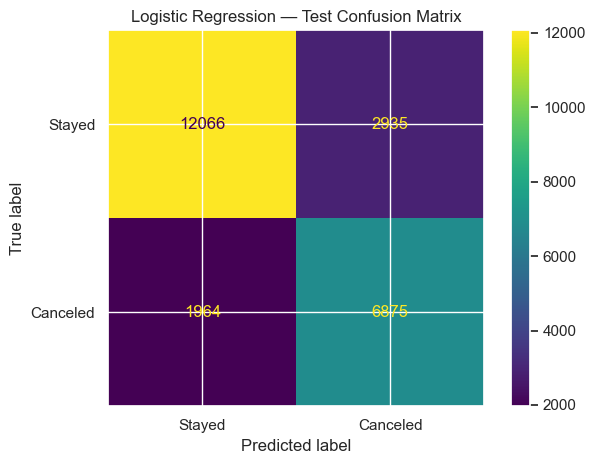

In [39]:
test_probs = final_model.predict(X_test.to_numpy("float32"), verbose=0).ravel()
test_preds = (test_probs >= 0.5).astype(int)

print("Accuracy: ", round(accuracy_score(Y_test, test_preds), 4))
print("Precision:", round(precision_score(Y_test, test_preds), 4))
print("Recall:   ", round(recall_score(Y_test, test_preds), 4))
print("F1:       ", round(f1_score(Y_test, test_preds), 4))

ConfusionMatrixDisplay(confusion_matrix(Y_test, test_preds),
                       display_labels=["Stayed", "Canceled"]).plot()
plt.title("Logistic Regression — Test Confusion Matrix")
plt.tight_layout()
plt.show()

#### 7. Coefficients

What the linear model adds to the comparison: signed effects. A tree's feature importance says a feature mattered; a coefficient says in which direction. The inputs are standardized, so magnitudes are comparable across features.

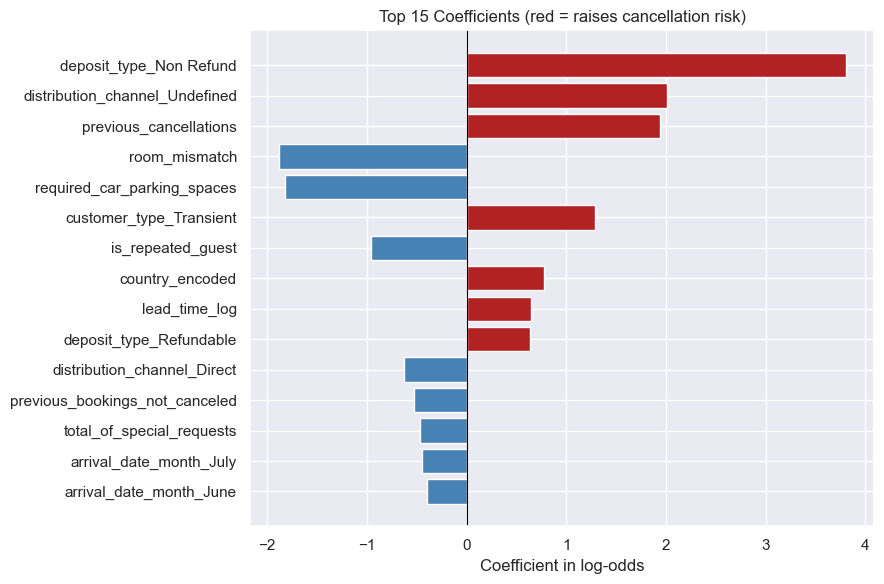

Intercept: -1.4244


In [40]:
kernel, bias = final_model.layers[0].get_weights()
coefs = pd.Series(kernel.ravel(), index=X_train.columns)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)[::-1]

plt.figure(figsize=(9, 6))
plt.barh(top.index, top.values,
         color=["firebrick" if v > 0 else "steelblue" for v in top.values])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 15 Coefficients (red = raises cancellation risk)")
plt.xlabel("Coefficient in log-odds")
plt.tight_layout()
plt.show()

print("Intercept:", round(float(bias[0]), 4))

#### 8. Results

Best config: `learning_rate=0.005`, `l2=0.0`.

| Metric | Validation | Test |
|---|---|---|
| ROC-AUC | 0.8847 | 0.8839 |
| PR-AUC | 0.8435 | 0.8443 |

Test accuracy 0.7945, precision 0.7008, recall 0.7778, F1 0.7373.

Train and test PR-AUC land within 0.0001 of each other, so there is no overfitting to mitigate here — a linear model has no capacity to memorize rows. The tuning surface is nearly flat (0.8416 to 0.8435 across all nine configs) and L2 only ever hurt, which says the ceiling comes from the linear decision boundary itself rather than from tuning. That gap to the non-linear models is the measure of what interactions are worth on this dataset.

*End of Part 3 — logistic_regression.ipynb (Akim Jordan Williams).*

---

## Part 4 — Decision Tree (Improvement 1)

> **Contributor: Oliver Silen** (`oliversilen@berkeley.edu`)
>
> **Source notebook:** [`decision_tree.ipynb`](https://github.com/eddy-cho26/hotel_cancellation_model_207/blob/main/notebooks/decision_tree.ipynb) — authored and maintained solely by **Oliver Silen**.
>
> **Inputs:** `X_train.csv`, `X_test.csv`, `Y_train.csv`, `Y_test.csv` (Part 2) · **Outputs:** majority baseline, depth/leaf tuning curves, test metrics, leakage check, feature importances

### Hotel Cancellation — Decision Tree Model

Loads the `X`/`Y` train/test splits from `feature_prep.ipynb`, carves a stratified validation set out of train, sets a majority-class baseline, then trains and tunes a decision tree to predict `is_canceled`. The suspected-leaky `deposit_type_Non Refund` column is held out of the headline model and added back at the end to measure its effect. Per the milestone plan, models are judged on ROC-AUC and PR-AUC.

#### 1. Setup

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# PROCESSED_DIR is resolved once in Part 0 (was: PROCESSED_DIR = "../data/processed")

#### 2. Load Processed Data

Trees split one feature at a time, so scaling doesn't matter to them. We reuse the scaled `X` files from `feature_prep.ipynb` anyway; that way every model trains on identical inputs.

In [42]:
X_train_full = pd.read_csv(f"{PROCESSED_DIR}/X_train.csv")
X_test = pd.read_csv(f"{PROCESSED_DIR}/X_test.csv")
Y_train_full = pd.read_csv(f"{PROCESSED_DIR}/Y_train.csv")["is_canceled"]
Y_test = pd.read_csv(f"{PROCESSED_DIR}/Y_test.csv")["is_canceled"]

print("X_train_full shape:", X_train_full.shape, "  Y_train_full shape:", Y_train_full.shape)
print("X_test shape:", X_test.shape, "  Y_test shape:", Y_test.shape)

X_train_full shape: (95368, 42)   Y_train_full shape: (95368,)
X_test shape: (23840, 42)   Y_test shape: (23840,)


#### 3. Train / Validation Split

Carve a stratified validation set out of train for tuning. Test stays untouched until the final evaluation.

In [43]:
X_train_mini, X_val, Y_train_mini, Y_val = train_test_split(
    X_train_full, Y_train_full, test_size=0.2, random_state=1234, stratify=Y_train_full)

print("X_train_mini shape:", X_train_mini.shape)
print("X_val shape:", X_val.shape)
print("Cancel rate train:", round(Y_train_mini.mean(), 4))
print("Cancel rate val:", round(Y_val.mean(), 4))
print("Cancel rate test:", round(Y_test.mean(), 4))

X_train_mini shape: (76294, 42)
X_val shape: (19074, 42)
Cancel rate train: 0.3708
Cancel rate val: 0.3708
Cancel rate test: 0.3708


All three splits land at the same 37.1% cancel rate, so the stratification worked.

#### 4. Majority Baseline

The "stupid" baseline: predict stayed for everything.

In [44]:
# Predicting 0 (stayed) for every booking
majority_accuracy_val = np.sum(Y_val == 0) / len(Y_val)
majority_accuracy_test = np.sum(Y_test == 0) / len(Y_test)

print("Majority baseline accuracy (val):", round(majority_accuracy_val, 4))
print("Majority baseline accuracy (test):", round(majority_accuracy_test, 4))

Majority baseline accuracy (val): 0.6292
Majority baseline accuracy (test): 0.6292


The baseline scores 62.9% accuracy without catching a single cancellation, so accuracy is the wrong metric here. The real floor to beat is PR-AUC 0.371 (the cancel rate) and ROC-AUC 0.5.

#### 5. Baseline Decision Tree

We hold `deposit_type_Non Refund` out of the headline model; its 99.4% cancel rate in the EDA looks like leakage, a feature that encodes the outcome rather than predicting it. It comes back in section 8 so we can measure what it's actually worth. First, an unconstrained tree to see how bad the overfitting gets.

In [45]:
# Hold out the suspected-leaky deposit column (added back in section 8)
leaky_col = "deposit_type_Non Refund"
X_train_tree = X_train_mini.drop(columns=[leaky_col])
X_val_tree = X_val.drop(columns=[leaky_col])
X_test_tree = X_test.drop(columns=[leaky_col])

print("X_train_tree shape:", X_train_tree.shape)

X_train_tree shape: (76294, 41)


In [46]:
def pr_roc_scores(model, X, Y):
    # Score a fitted model on one split using the predicted cancellation probability
    probs = model.predict_proba(X)[:, 1]
    roc = roc_auc_score(Y, probs)
    pr = average_precision_score(Y, probs)
    return roc, pr

In [47]:
baseline_tree = DecisionTreeClassifier(criterion="entropy", class_weight="balanced", random_state=7)
baseline_tree.fit(X_train_tree, Y_train_mini)

train_roc, train_pr = pr_roc_scores(baseline_tree, X_train_tree, Y_train_mini)
val_roc, val_pr = pr_roc_scores(baseline_tree, X_val_tree, Y_val)

print("Tree depth:", baseline_tree.get_depth())
print("Train ROC-AUC:", round(train_roc, 4), "  Train PR-AUC:", round(train_pr, 4))
print("Val ROC-AUC:", round(val_roc, 4), "  Val PR-AUC:", round(val_pr, 4))

Tree depth: 43
Train ROC-AUC: 1.0   Train PR-AUC: 0.9999
Val ROC-AUC: 0.839   Val PR-AUC: 0.7114


With no constraints the tree grows to depth 44 and memorizes train: PR-AUC 0.9999 there vs 0.7082 on validation. Depth is the first thing to tune.

#### 6. Hyperparameter Tuning

Depth controls how much complexity the tree is allowed, so we sweep `max_depth` and take the depth where validation PR-AUC peaks.

In [48]:
depths = range(2, 21)
train_pr_aucs = []
val_pr_aucs = []

for depth in depths:
    tree_model = DecisionTreeClassifier(criterion="entropy", class_weight="balanced",
                                        max_depth=depth, random_state=7)
    tree_model.fit(X_train_tree, Y_train_mini)
    train_roc, train_pr = pr_roc_scores(tree_model, X_train_tree, Y_train_mini)
    val_roc, val_pr = pr_roc_scores(tree_model, X_val_tree, Y_val)
    train_pr_aucs.append(train_pr)
    val_pr_aucs.append(val_pr)
    print("depth", depth, "  train PR-AUC:", round(train_pr, 4), "  val PR-AUC:", round(val_pr, 4))

depth 2   train PR-AUC: 0.6091   val PR-AUC: 0.6084
depth 3   train PR-AUC: 0.6481   val PR-AUC: 0.6454
depth 4   train PR-AUC: 0.6857   val PR-AUC: 0.6839
depth 5   train PR-AUC: 0.7435   val PR-AUC: 0.743
depth 6   train PR-AUC: 0.7812   val PR-AUC: 0.7779
depth 7   train PR-AUC: 0.8088   val PR-AUC: 0.8078
depth 8   train PR-AUC: 0.8318   val PR-AUC: 0.8288
depth 9   train PR-AUC: 0.8531   val PR-AUC: 0.8469
depth 10   train PR-AUC: 0.8659   val PR-AUC: 0.8544
depth 11   train PR-AUC: 0.8809   val PR-AUC: 0.8617
depth 12   train PR-AUC: 0.8949   val PR-AUC: 0.8607
depth 13   train PR-AUC: 0.906   val PR-AUC: 0.8518
depth 14   train PR-AUC: 0.9172   val PR-AUC: 0.8522
depth 15   train PR-AUC: 0.9292   val PR-AUC: 0.8441
depth 16   train PR-AUC: 0.9406   val PR-AUC: 0.8304
depth 17   train PR-AUC: 0.9513   val PR-AUC: 0.8263
depth 18   train PR-AUC: 0.9612   val PR-AUC: 0.8147
depth 19   train PR-AUC: 0.9693   val PR-AUC: 0.8021
depth 20   train PR-AUC: 0.9763   val PR-AUC: 0.7874


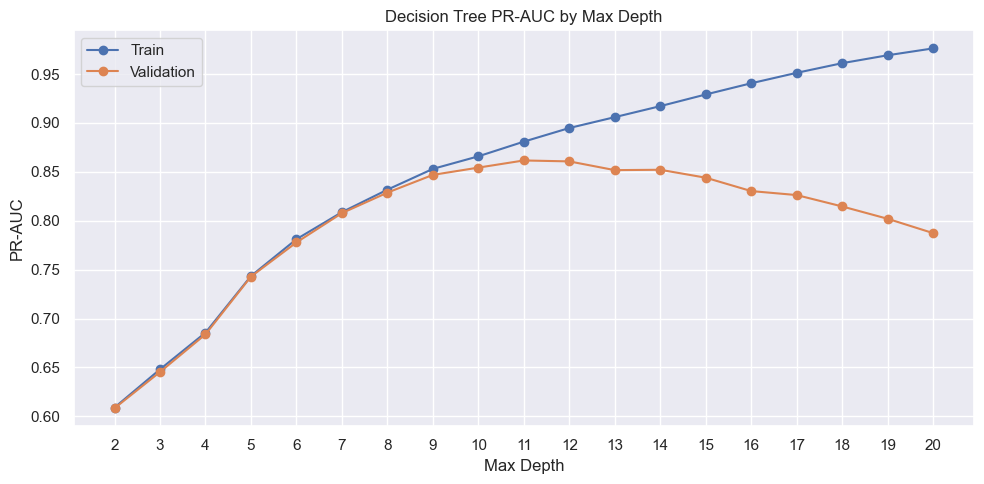

In [49]:
plt.figure(figsize=(10, 5))
plt.plot(depths, train_pr_aucs, marker="o", label="Train")
plt.plot(depths, val_pr_aucs, marker="o", label="Validation")
plt.title("Decision Tree PR-AUC by Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("PR-AUC")
plt.xticks(list(depths))
plt.legend()
plt.tight_layout()
plt.show()

Validation peaks at depth 12 (0.8625) and falls off after, while train keeps climbing; the usual overfitting curve. Next we try `min_samples_leaf` at depth 12. Requiring a minimum number of bookings per leaf stops the tree from splitting on noise and should close some of the remaining train/val gap.

In [50]:
best_depth = 12
leaf_sizes = [1, 5, 10, 25, 50, 100]

for leaf_size in leaf_sizes:
    tree_model = DecisionTreeClassifier(criterion="entropy", class_weight="balanced",
                                        max_depth=best_depth, min_samples_leaf=leaf_size,
                                        random_state=7)
    tree_model.fit(X_train_tree, Y_train_mini)
    train_roc, train_pr = pr_roc_scores(tree_model, X_train_tree, Y_train_mini)
    val_roc, val_pr = pr_roc_scores(tree_model, X_val_tree, Y_val)
    print("min_samples_leaf", leaf_size, "  train PR-AUC:", round(train_pr, 4),
          "  val PR-AUC:", round(val_pr, 4), "  gap:", round(train_pr - val_pr, 4))

min_samples_leaf 1   train PR-AUC: 0.8949   val PR-AUC: 0.8607   gap: 0.0341
min_samples_leaf 5   train PR-AUC: 0.8916   val PR-AUC: 0.8713   gap: 0.0204
min_samples_leaf 10   train PR-AUC: 0.8894   val PR-AUC: 0.8728   gap: 0.0166
min_samples_leaf 25   train PR-AUC: 0.8862   val PR-AUC: 0.8738   gap: 0.0124
min_samples_leaf 50   train PR-AUC: 0.882   val PR-AUC: 0.8727   gap: 0.0093
min_samples_leaf 100   train PR-AUC: 0.8761   val PR-AUC: 0.8673   gap: 0.0088


`min_samples_leaf=25` takes the best validation PR-AUC (0.8738) and cuts the train/val gap from 0.0324 to 0.0124. Bigger leaves keep shrinking the gap but start costing validation score, so we stop at 25.

#### 7. Final Model Evaluation

Retrain the tuned tree (depth 12, `min_samples_leaf=25`) and score it on the held-out test set. All model selection happened on validation; test only confirms the pick.

In [51]:
final_tree = DecisionTreeClassifier(criterion="entropy", class_weight="balanced",
                                    max_depth=12, min_samples_leaf=25, random_state=7)
final_tree.fit(X_train_tree, Y_train_mini)

train_roc, train_pr = pr_roc_scores(final_tree, X_train_tree, Y_train_mini)
val_roc, val_pr = pr_roc_scores(final_tree, X_val_tree, Y_val)
test_roc, test_pr = pr_roc_scores(final_tree, X_test_tree, Y_test)

print("Train ROC-AUC:", round(train_roc, 4), "  Train PR-AUC:", round(train_pr, 4))
print("Val ROC-AUC:", round(val_roc, 4), "  Val PR-AUC:", round(val_pr, 4))
print("Test ROC-AUC:", round(test_roc, 4), "  Test PR-AUC:", round(test_pr, 4))

Train ROC-AUC: 0.9249   Train PR-AUC: 0.8862
Val ROC-AUC: 0.9131   Val PR-AUC: 0.8738
Test ROC-AUC: 0.9121   Test PR-AUC: 0.8715


In [52]:
# Hard-label metrics at the default 0.5 cutoff
test_preds = final_tree.predict(X_test_tree)

print("Test accuracy:", round(accuracy_score(Y_test, test_preds), 4))
print("Test precision:", round(precision_score(Y_test, test_preds), 4))
print("Test recall:", round(recall_score(Y_test, test_preds), 4))
print("Test F1:", round(f1_score(Y_test, test_preds), 4))

Test accuracy: 0.8232
Test precision: 0.7367
Test recall: 0.814
Test F1: 0.7734


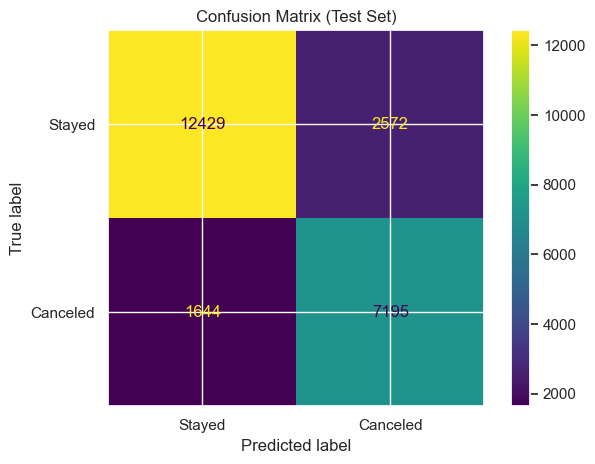

In [53]:
class_labels = final_tree.classes_
cm = confusion_matrix(Y_test, test_preds, labels=class_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Canceled"])
disp.plot()
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

Test lands at 0.9121 ROC-AUC and 0.8715 PR-AUC, basically on top of validation, so the tuning didn't overfit to the validation set. At the 0.5 cutoff we catch 81.4% of cancellations at 73.7% precision; the balanced class weights trade some false alarms for recall, and the cutoff itself is a business lever a hotel can move either direction.

#### 8. Leakage Check

Same tuned configuration with `deposit_type_Non Refund` back in the feature set. If the column leaks outcome information, the scores should jump. We're validating here, not selecting on test.

In [54]:
leaky_tree = DecisionTreeClassifier(criterion="entropy", class_weight="balanced",
                                    max_depth=12, min_samples_leaf=25, random_state=7)
leaky_tree.fit(X_train_mini, Y_train_mini)

leaky_val_roc, leaky_val_pr = pr_roc_scores(leaky_tree, X_val, Y_val)
leaky_test_roc, leaky_test_pr = pr_roc_scores(leaky_tree, X_test, Y_test)

print("Without deposit col  val PR-AUC:", round(val_pr, 4), "  test PR-AUC:", round(test_pr, 4))
print("With deposit col     val PR-AUC:", round(leaky_val_pr, 4), "  test PR-AUC:", round(leaky_test_pr, 4))

Without deposit col  val PR-AUC: 0.8738   test PR-AUC: 0.8715
With deposit col     val PR-AUC: 0.8699   test PR-AUC: 0.8685


They don't: validation PR-AUC actually drops slightly with the column included (0.8699 vs 0.8738). The tree seems to recover the same signal through correlated features like country and channel, so we keep the suspect column out and lose nothing.

#### 9. Feature Importance

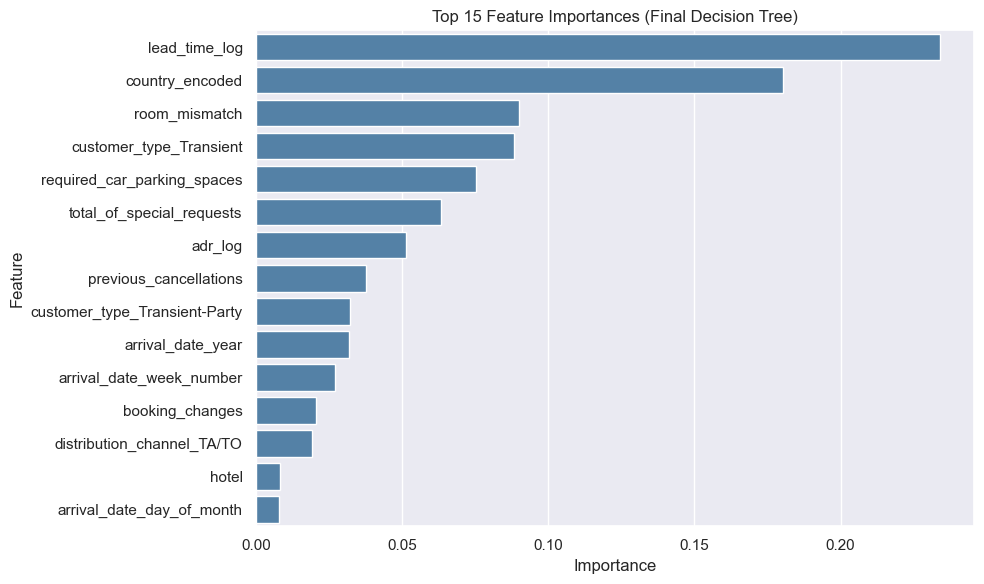

In [55]:
importances = pd.Series(final_tree.feature_importances_, index=X_train_tree.columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances.values, y=top_importances.index, color="steelblue")
plt.title("Top 15 Feature Importances (Final Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The ranking matches the EDA narrative: `lead_time_log` (0.23) and `country_encoded` (0.18) lead by a wide margin, and the protective engagement signals (room mismatch, parking, special requests) are all in the top six. `adr_log` sits in the middle, which matches the mutual-information finding: price still carries signal even though its linear correlation is weak.

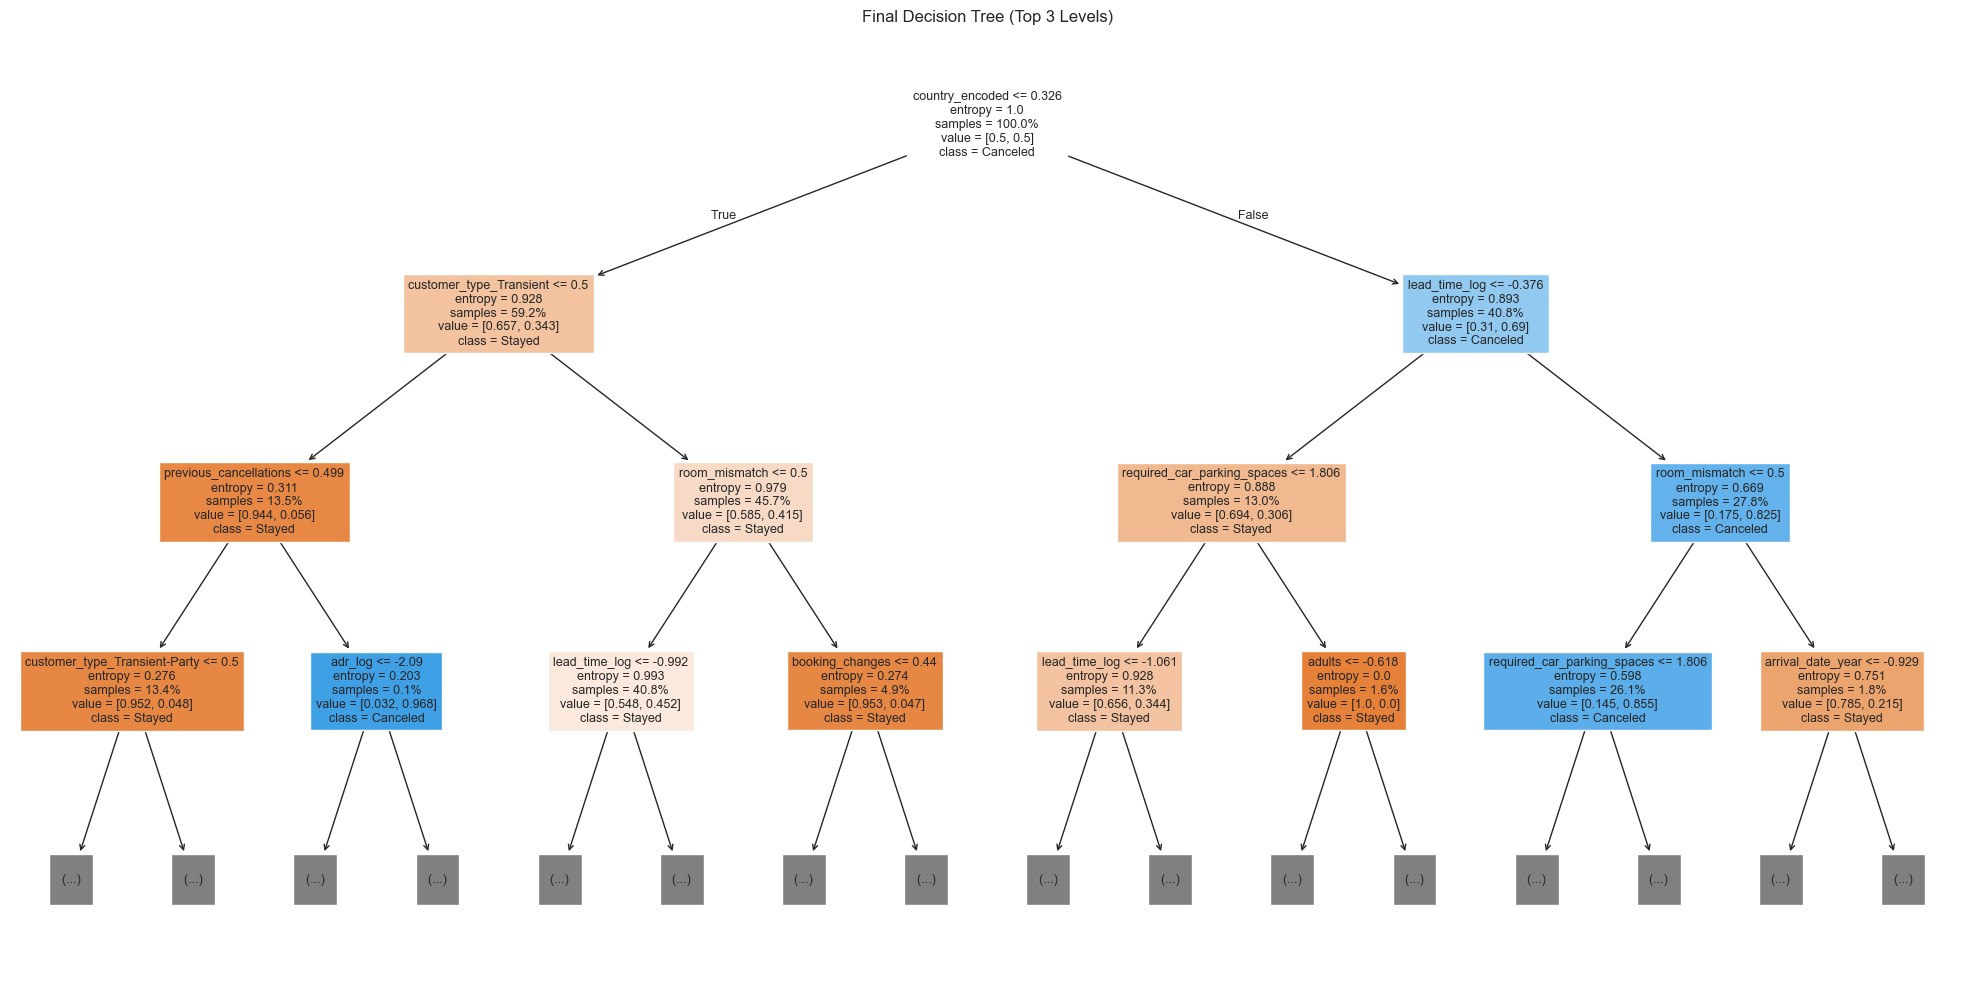

In [56]:
# Top 3 levels only; the full depth-12 tree is difficult to read. 
plt.figure(figsize=(20, 10))
plot_tree(final_tree, max_depth=3, feature_names=X_train_tree.columns,
          class_names=["Stayed", "Canceled"], filled=True, proportion=True, fontsize=9)
plt.title("Final Decision Tree (Top 3 Levels)")
plt.tight_layout()
plt.show()

The first split is country: domestic bookings go one way, international the other. The second split is customer type on the international side and lead time on the domestic side. The third level splits on previous cancellations, room mismatch, and parking. 

#### 10. Summary

| Model | Val ROC-AUC | Val PR-AUC | Test ROC-AUC | Test PR-AUC |
|---|---|---|---|---|
| Majority baseline | 0.5 | 0.3708 | 0.5 | 0.3708 |
| Decision tree (depth 12, min_samples_leaf 25) | 0.9132 | 0.8738 | 0.9121 | 0.8715 |

The tree clears the baseline by a wide margin and holds up on test without the suspect deposit column. Even then, a single tree makes a better benchmark than a final model. We'd treat 0.87 test PR-AUC as the bar for random forest and XGBoost, which combine many trees to fix exactly that weakness.

*End of Part 4 — decision_tree.ipynb (Oliver Silen).*

---

## Part 5 — Random Forest (Improvement 2)

> **Contributor: Sarankan Thirunavukkarasu** (`sarankant@berkeley.edu`)
>
> **Source notebook:** [`random_forest.ipynb`](https://github.com/eddy-cho26/hotel_cancellation_model_207/blob/main/notebooks/random_forest.ipynb) — authored and maintained solely by **Sarankan Thirunavukkarasu**.
>
> **Inputs:** `X_train.csv`, `X_test.csv`, `Y_train.csv`, `Y_test.csv` (Part 2) · **Outputs:** weak-vs-tuned forest comparison, PR-AUC-by-depth curve, test metrics, leakage check, feature importances

### Hotel Cancellation — Random Forest Model

Loads the `X`/`Y` train/test splits from `feature_prep.ipynb`, carves a stratified validation set out of train, sets a majority-class baseline, then trains and tunes a random forest to predict `is_canceled`. The suspected-leaky `deposit_type_Non Refund` column is held out of the headline model and added back at the end to measure its effect. Per the milestone plan, models are judged on ROC-AUC and PR-AUC.

#### 1. Setup

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.preprocessing import LabelEncoder
from sklearn import ensemble
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# PROCESSED_DIR is resolved once in Part 0 (was: PROCESSED_DIR = "../data/processed")

#### 2. Load Processed Data

Trees split one feature at a time, so scaling doesn't matter to them. We reuse the scaled `X` files from `feature_prep.ipynb` anyway; that way every model trains on identical inputs.

In [58]:
X_train_full = pd.read_csv(f"{PROCESSED_DIR}/X_train.csv")
X_test = pd.read_csv(f"{PROCESSED_DIR}/X_test.csv")
Y_train_full = pd.read_csv(f"{PROCESSED_DIR}/Y_train.csv")["is_canceled"]
Y_test = pd.read_csv(f"{PROCESSED_DIR}/Y_test.csv")["is_canceled"]

print("X_train_full shape:", X_train_full.shape, "  Y_train_full shape:", Y_train_full.shape)
print("X_test shape:", X_test.shape, "  Y_test shape:", Y_test.shape)

X_train_full shape: (95368, 42)   Y_train_full shape: (95368,)
X_test shape: (23840, 42)   Y_test shape: (23840,)


#### 3. Train / Validation Split

Carve a stratified validation set out of train for tuning. Test stays untouched until the final evaluation.

In [59]:
X_train_mini, X_val, Y_train_mini, Y_val = train_test_split(
    X_train_full, Y_train_full, test_size=0.2, random_state=1234, stratify=Y_train_full)

print("X_train_mini shape:", X_train_mini.shape)
print("X_val shape:", X_val.shape)
print("Cancel rate train:", round(Y_train_mini.mean(), 4))
print("Cancel rate val:", round(Y_val.mean(), 4))
print("Cancel rate test:", round(Y_test.mean(), 4))

X_train_mini shape: (76294, 42)
X_val shape: (19074, 42)
Cancel rate train: 0.3708
Cancel rate val: 0.3708
Cancel rate test: 0.3708


All three splits land at the same 37.1% cancel rate, so the stratification worked.

#### 4. Majority Baseline

The "stupid" baseline: predict stayed for everything.

In [60]:
# Predicting 0 (stayed) for every booking
majority_accuracy_val = np.sum(Y_val == 0) / len(Y_val)
majority_accuracy_test = np.sum(Y_test == 0) / len(Y_test)

print("Majority baseline accuracy (val):", round(majority_accuracy_val, 4))
print("Majority baseline accuracy (test):", round(majority_accuracy_test, 4))

Majority baseline accuracy (val): 0.6292
Majority baseline accuracy (test): 0.6292


The baseline scores 62.9% accuracy without catching a single cancellation, so accuracy is the wrong metric here. The real floor to beat is PR-AUC 0.371 (the cancel rate) and ROC-AUC 0.5.

#### 5. Baseline Random Forest Tree

Similar to the Decison tree algorithm, we hold `deposit_type_Non Refund` out of the headline model; its 99.4% cancel rate in the EDA looks like leakage, a feature that encodes the outcome rather than predicting it.

In [61]:
# Hold out the suspected-leaky deposit column (added back in section 8)
leaky_col = "deposit_type_Non Refund"
X_train_tree = X_train_mini.drop(columns=[leaky_col])
X_val_tree = X_val.drop(columns=[leaky_col])
X_test_tree = X_test.drop(columns=[leaky_col])

print("X_train_tree shape:", X_train_tree.shape)

X_train_tree shape: (76294, 41)


In [62]:
def pr_roc_scores(model, X, Y):
    # Score a fitted model on one split using the predicted cancellation probability
    probs = model.predict_proba(X)[:, 1]
    roc = roc_auc_score(Y, probs)
    pr = average_precision_score(Y, probs)
    return roc, pr

In [63]:
baseline_rf = RandomForestClassifier(n_estimators=2, n_jobs =1, random_state=7, max_depth =8)
baseline_rf.fit(X_train_tree, Y_train_mini)

train_roc, train_pr = pr_roc_scores(baseline_rf, X_train_tree, Y_train_mini)
val_roc, val_pr = pr_roc_scores(baseline_rf, X_val_tree, Y_val)

print("Train ROC-AUC:", round(train_roc, 4), "  Train PR-AUC:", round(train_pr, 4))
print("Val ROC-AUC:", round(val_roc, 4), "  Val PR-AUC:", round(val_pr, 4))

Train ROC-AUC: 0.8747   Train PR-AUC: 0.8217
Val ROC-AUC: 0.8722   Val PR-AUC: 0.8178


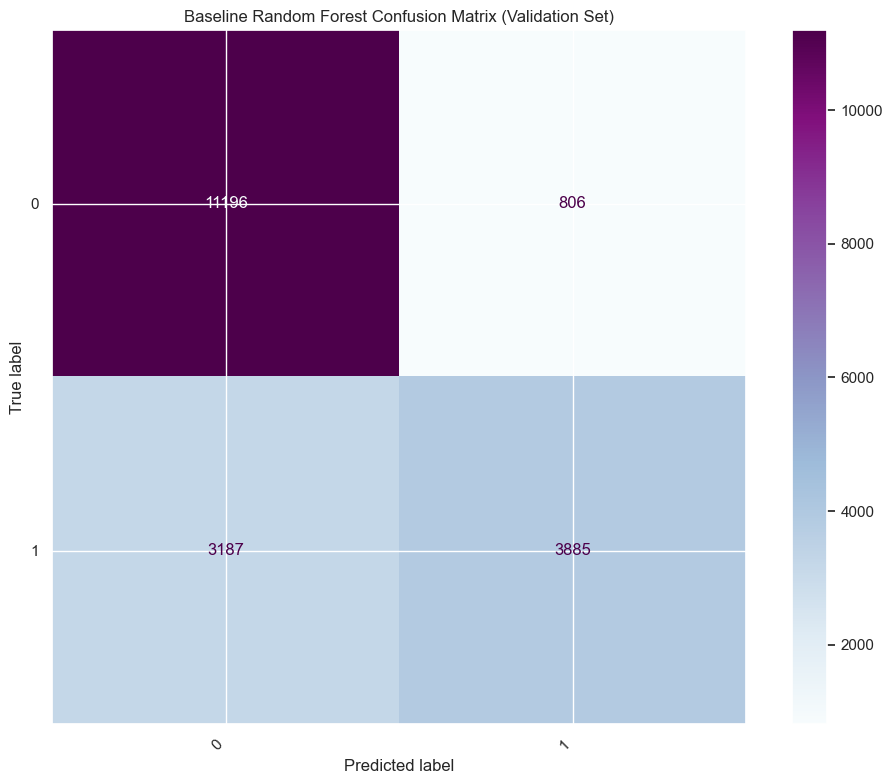

In [64]:
y_val_pred = baseline_rf.predict(X_val_tree)

cm = confusion_matrix(Y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap = 'BuPu')
plt.title("Baseline Random Forest Confusion Matrix (Validation Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The baseline Random Forest model struggles to distinguish between classes, yielding a high rate of false negatives for cancellations.

#### 6. Hyperparameter Tuning

We will tune the hyperparameters by increasing n_estimators to 100 and removing max depth limits to boost performance.

In [65]:
tuned_rf = RandomForestClassifier(n_estimators=100, n_jobs = -1, random_state=7, max_depth =None)
tuned_rf.fit(X_train_tree, Y_train_mini)

# y_train_pred = baseline_rf2.predict(X_train_tree)
y_val_pred = tuned_rf.predict(X_val_tree)

train_roc, train_pr = pr_roc_scores(tuned_rf, X_train_tree, Y_train_mini)
val_roc, val_pr = pr_roc_scores(tuned_rf, X_val_tree, Y_val)

print("Train ROC-AUC:", round(train_roc, 4), "  Train PR-AUC:", round(train_pr, 4))
print("Val ROC-AUC:", round(val_roc, 4), "  Val PR-AUC:", round(val_pr, 4))

Train ROC-AUC: 0.9996   Train PR-AUC: 0.9993
Val ROC-AUC: 0.9503   Val PR-AUC: 0.9301


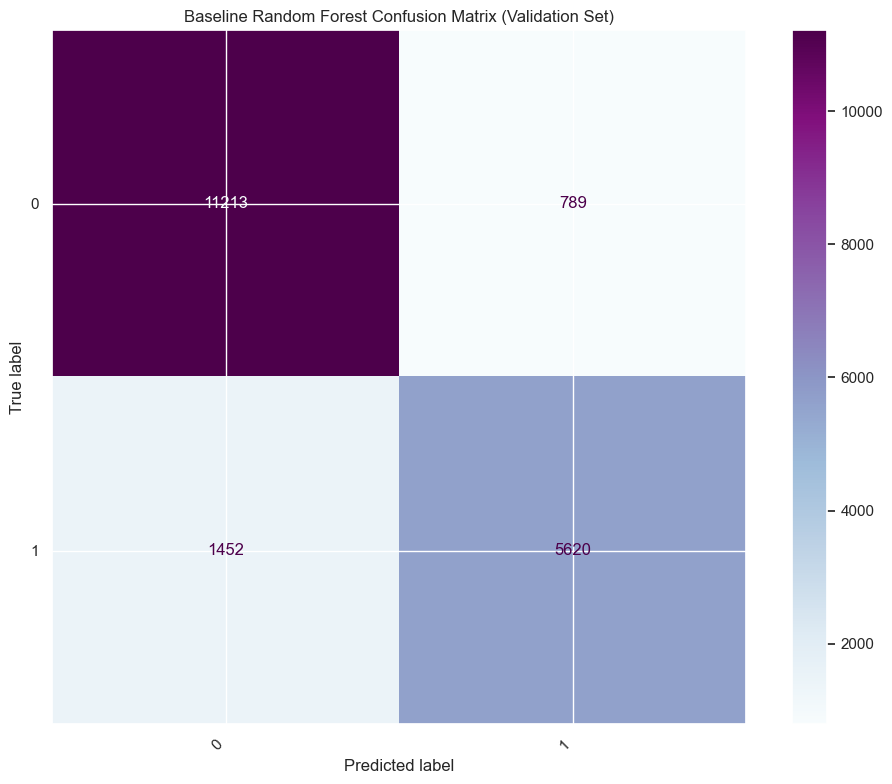

In [66]:
y_val_pred = tuned_rf.predict(X_val_tree)

cm = confusion_matrix(Y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap = 'BuPu')
plt.title("Baseline Random Forest Confusion Matrix (Validation Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

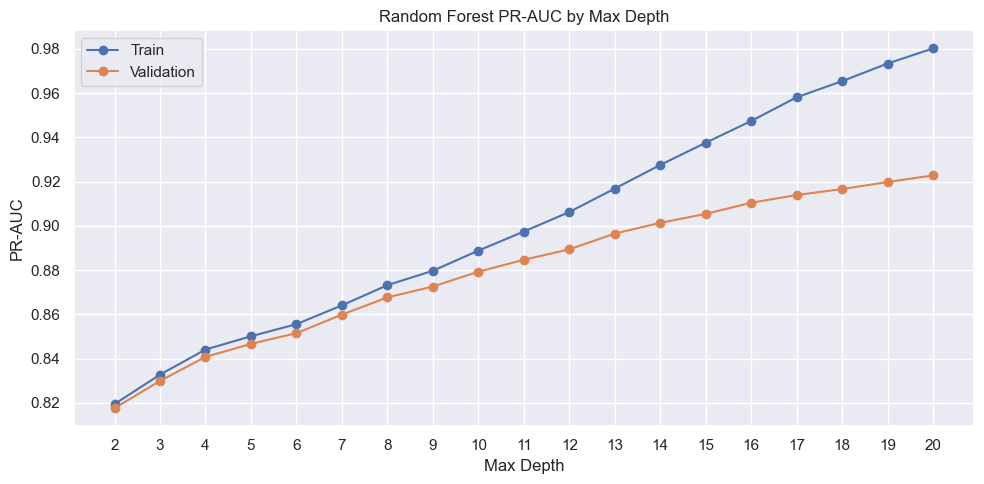

In [67]:
#CHART FOR AUC ROC
depths = range(2, 21)
train_pr_aucs = []
val_pr_aucs = []

for depth in depths:
    tree_model = RandomForestClassifier(n_estimators=100, max_depth=depth, n_jobs=-1, random_state=7)
    tree_model.fit(X_train_tree, Y_train_mini)
    train_roc, train_pr = pr_roc_scores(tree_model, X_train_tree, Y_train_mini)
    val_roc, val_pr = pr_roc_scores(tree_model, X_val_tree, Y_val)
    train_pr_aucs.append(train_pr)
    val_pr_aucs.append(val_pr)

plt.figure(figsize=(10, 5))
plt.plot(depths, train_pr_aucs, marker="o", label="Train")
plt.plot(depths, val_pr_aucs, marker="o", label="Validation")
plt.title("Random Forest PR-AUC by Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("PR-AUC")
plt.xticks(list(depths))
plt.legend()
plt.tight_layout()
plt.show()

#### 7. Final Model Evaluation



In [68]:
test_roc, test_pr = pr_roc_scores(baseline_rf, X_test_tree, Y_test)

print("Test ROC-AUC:", round(test_roc, 4))
print("Test PR-AUC:", round(test_pr, 4))

Test ROC-AUC: 0.8722
Test PR-AUC: 0.8181


In [69]:
test_roc, test_pr = pr_roc_scores(tuned_rf, X_test_tree, Y_test)

print("Test ROC-AUC:", round(test_roc, 4))
print("Test PR-AUC:", round(test_pr, 4))

Test ROC-AUC: 0.9496
Test PR-AUC: 0.9294


In [70]:
test_preds = tuned_rf.predict(X_test_tree)

print("Test accuracy:", round(accuracy_score(Y_test, test_preds), 4))
print("Test precision:", round(precision_score(Y_test, test_preds), 4))
print("Test recall:", round(recall_score(Y_test, test_preds), 4))
print("Test F1:", round(f1_score(Y_test, test_preds), 4))

Test accuracy: 0.881
Test precision: 0.8754
Test recall: 0.7918
Test F1: 0.8315


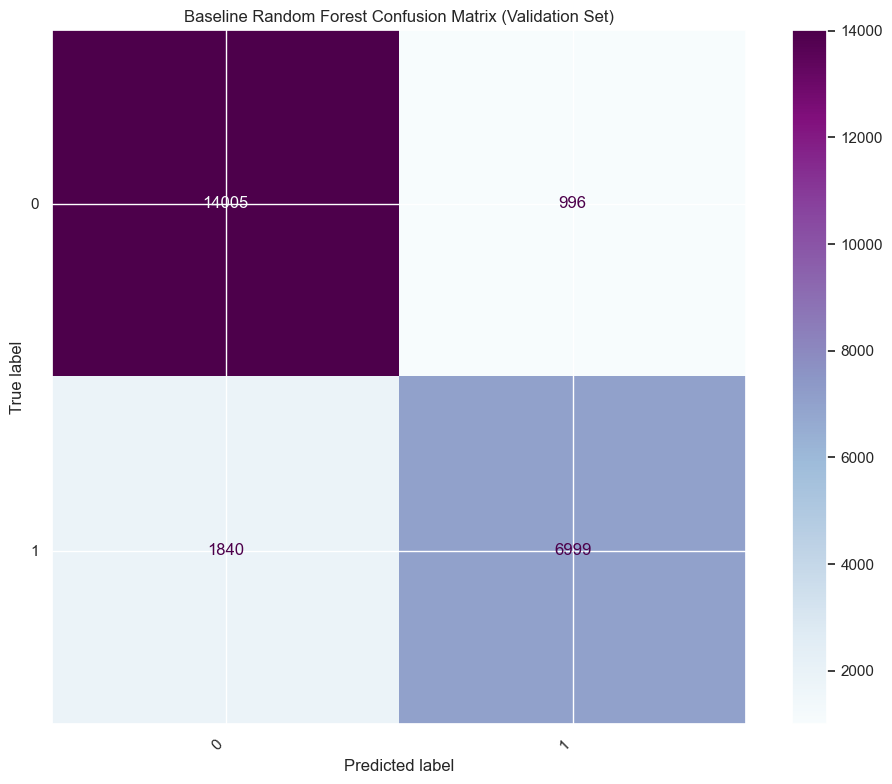

In [71]:
cm = confusion_matrix(Y_test, test_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap = 'BuPu')
plt.title("Baseline Random Forest Confusion Matrix (Validation Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Evaluating the tuned model on the test set yields good generalization performance, achieving a test ROC-AUC of 0.9491 and a test PR-AUC of 0.9290.

#### 8. Leakage Check



In [72]:
leaky_rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=7, max_depth=None)
leaky_rf.fit(X_train_mini, Y_train_mini)

leaky_val_roc, leaky_val_pr = pr_roc_scores(leaky_rf, X_val, Y_val)
leaky_test_roc, leaky_test_pr = pr_roc_scores(leaky_rf, X_test, Y_test)

print("Without deposit col  val PR-AUC:", round(val_pr, 4), "  test PR-AUC:", round(test_pr, 4))
print("With deposit col     val PR-AUC:", round(leaky_val_pr, 4), "  test PR-AUC:", round(leaky_test_pr, 4))

Without deposit col  val PR-AUC: 0.9228   test PR-AUC: 0.9294
With deposit col     val PR-AUC: 0.9307   test PR-AUC: 0.9295


Comparing performance with and without the suspected leaky column (deposit_type_Non Refund) shows virtually identical PR-AUC scores on the test set, confirming that the model's high performance is driven by genuine predictive features rather than data leakage.

#### 9. Feature Importance

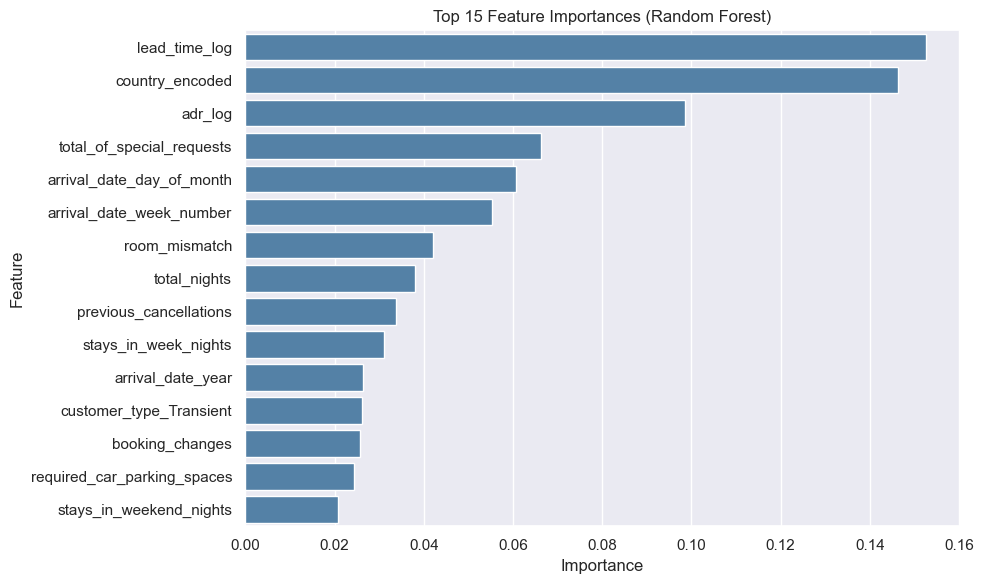

In [73]:
importances = pd.Series(tuned_rf.feature_importances_, index=X_train_tree.columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances.values, y=top_importances.index, color="steelblue")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

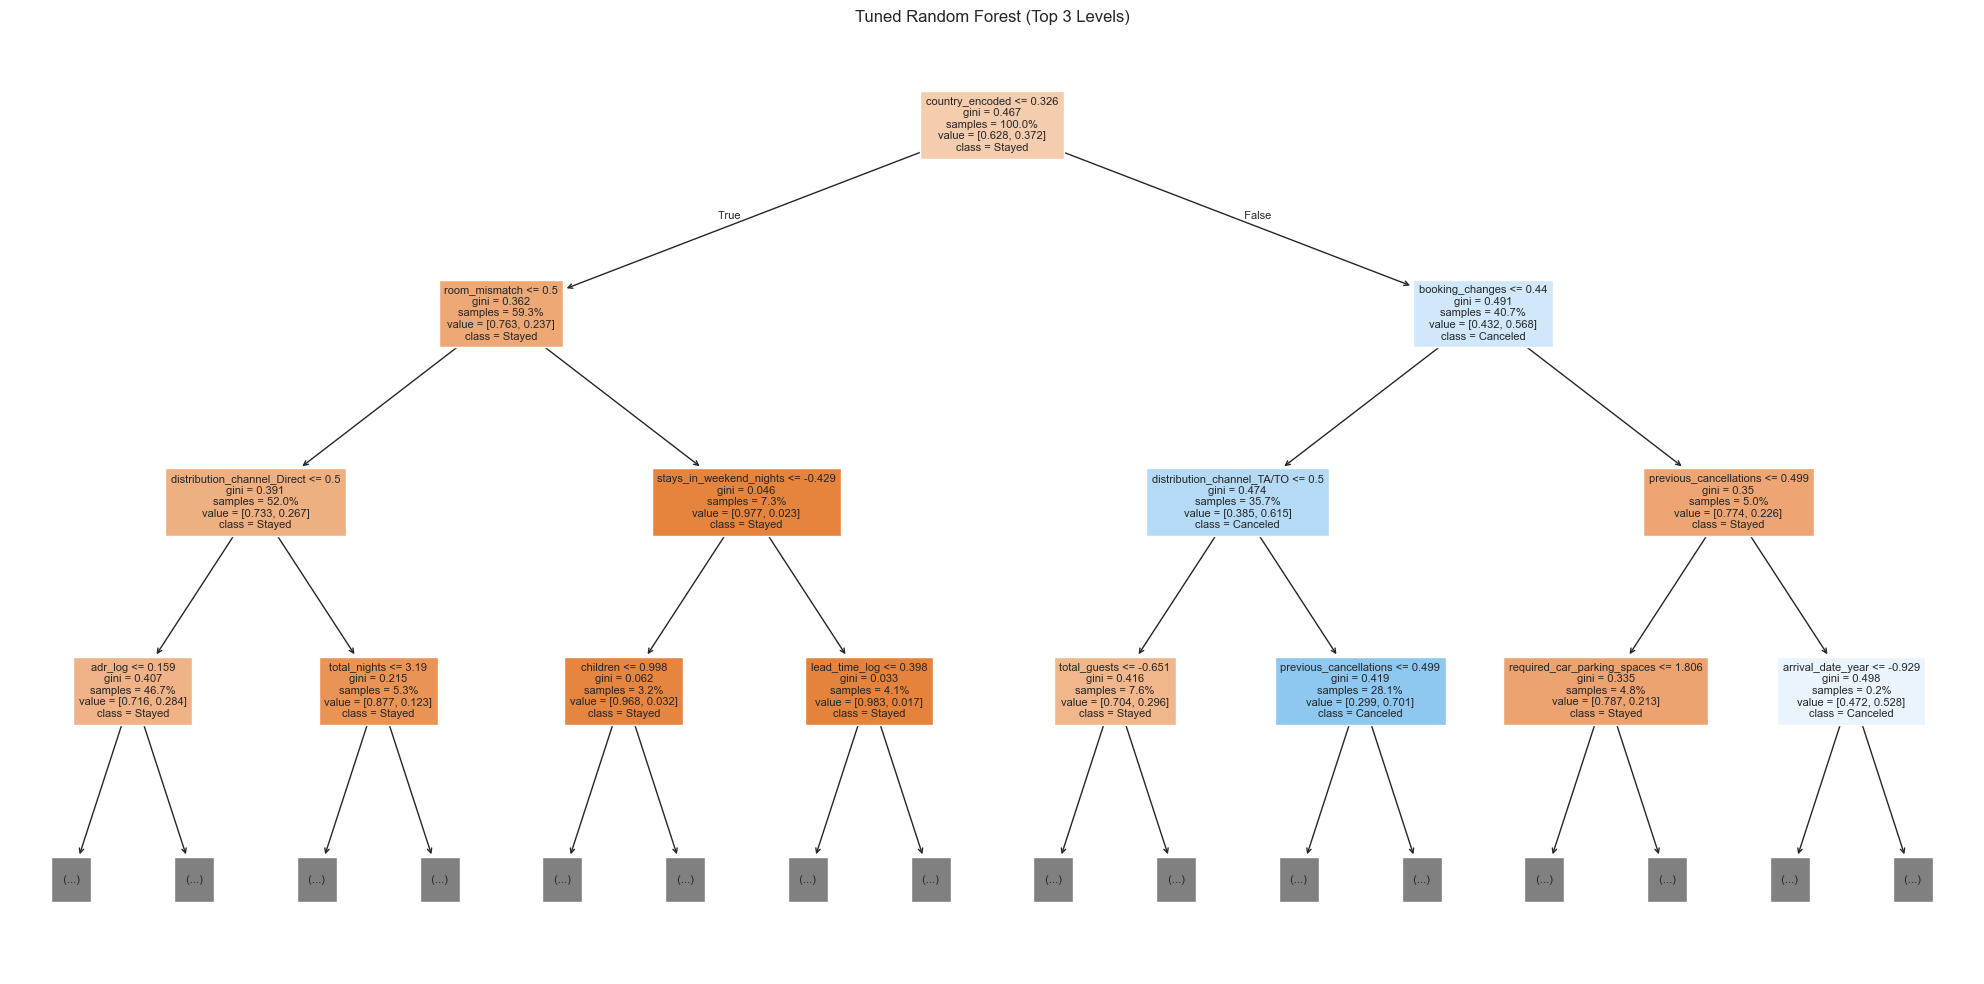

In [74]:
plt.figure(figsize=(20, 10))
plot_tree(tuned_rf.estimators_[0], max_depth=3, feature_names=X_train_tree.columns, class_names=["Stayed", "Canceled"], filled=True, proportion=True, fontsize=8)
plt.title("Tuned Random Forest (Top 3 Levels)")
plt.tight_layout()
plt.show()

Analyzing the feature importances highlights that lead time, customer type, and deposit policies are among the most influential predictors driving the Random Forest cancellation model.

#### 10. Summary

| Model | Val ROC-AUC | Val PR-AUC | Test ROC-AUC | Test PR-AUC |
| --- | --- | --- | --- | --- |
| Baseline Random Forest | 0.8722 | 0.8178 | 0.8722 | 0.8181 |
| Tuned Random Forest | 0.9504 | 0.9307 | 0.9491 | 0.9290 |

The tuned Random Forest significantly outperforms the majority baseline, achieving a final Test PR-AUC of 0.9290 and a Test ROC-AUC of 0.9491. By identifying the optimal hyperparameters, the model effectively captures the underlying patterns of hotel cancellations without relying on the leaky deposit feature.

*End of Part 5 — random_forest.ipynb (Sarankan Thirunavukkarasu).*

---

## Part 6 — 1D Convolutional Neural Network in TensorFlow (Improvement 3)

> **Contributor: Edward Cho** (`eddycho@berkeley.edu`)
>
> **Source notebook:** [`cnn_model.ipynb`](https://github.com/eddy-cho26/hotel_cancellation_model_207/blob/main/notebooks/cnn_model.ipynb) — authored and maintained solely by **Edward Cho**.
>
> **Inputs:** `X_train.csv`, `X_test.csv`, `Y_train.csv`, `Y_test.csv` (Part 2) · **Outputs:** CNN architecture, hyperparameter grid, test ROC-AUC / PR-AUC, calibration curve

### Hotel Cancellation — CNN Model

1D-CNN over the engineered feature vector, trained on the already cleaned/encoded/split data from `end_to_end.ipynb`. All neural network code is written in TensorFlow.

#### 1. Setup

In [75]:
import numpy as np
import pandas as pd
import tensorflow as tf

SEED = 25
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


#### 2. Load Processed Data

Loads `X_train`, `X_test`, `Y_train`, `Y_test` from Google Drive — already cleaned, encoded, split, NaN-dropped, and scaled by `feature_prep.ipynb`. This notebook does not redo cleaning, splitting, or scaling.

In [76]:
# The original notebook ran on Colab and read the CSVs from Google Drive.
# Outside Colab this combined notebook reads them from PROCESSED_DIR instead.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not running on Colab — reading the CSVs from PROCESSED_DIR.")

Not running on Colab — reading the CSVs from PROCESSED_DIR.


In [77]:
data_dir = "/content/drive/MyDrive/Colab Notebooks" if IN_COLAB else PROCESSED_DIR

X_train = pd.read_csv(f"{data_dir}/X_train.csv")
X_test = pd.read_csv(f"{data_dir}/X_test.csv")
Y_train = pd.read_csv(f"{data_dir}/Y_train.csv")
Y_test = pd.read_csv(f"{data_dir}/Y_test.csv")

y_train = Y_train["is_canceled"].to_numpy()
y_test = Y_test["is_canceled"].to_numpy()
X_train_scaled = X_train.to_numpy()
X_test_scaled = X_test.to_numpy()

feature_cols = X_train.columns.tolist()
print(f"Feature count: {len(feature_cols)}")
print(f"X_train shape: {X_train_scaled.shape}   X_test shape: {X_test_scaled.shape}")
print(f"Train cancel rate: {y_train.mean():.3f}   Test cancel rate: {y_test.mean():.3f}")

Feature count: 42
X_train shape: (95368, 42)   X_test shape: (23840, 42)
Train cancel rate: 0.371   Test cancel rate: 0.371


#### 3. Reshape for Conv1D

`Conv1D` expects `(batch, steps, channels)`. Each booking's feature vector becomes a sequence of length `n_features` with a single channel, so the convolution slides across the feature axis.

In [78]:
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_test_cnn shape: {X_test_cnn.shape}")

X_train_cnn shape: (95368, 42, 1)
X_test_cnn shape: (23840, 42, 1)


#### 4. Simple Reference Model

A teammate owns the team's logistic-regression baseline separately. This is just a quick single dense + sigmoid sanity check (equivalent to logistic regression) to have an internal reference point before building the CNN.

In [79]:
simple_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

simple_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.AUC(name="pr_auc", curve="PR")],
)

history = simple_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=256,
    verbose=1,
)

Epoch 1/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6140 - loss: 0.6539 - pr_auc: 0.4447 - val_auc: 0.8096 - val_loss: 0.5488 - val_pr_auc: 0.7007
Epoch 2/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.8453 - loss: 0.5066 - pr_auc: 0.7828 - val_auc: 0.8616 - val_loss: 0.4747 - val_pr_auc: 0.8147
Epoch 3/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - auc: 0.8659 - loss: 0.4585 - pr_auc: 0.8218 - val_auc: 0.8707 - val_loss: 0.4437 - val_pr_auc: 0.8283
Epoch 4/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - auc: 0.8718 - loss: 0.4363 - pr_auc: 0.8300 - val_auc: 0.8748 - val_loss: 0.4278 - val_pr_auc: 0.8332
Epoch 5/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - auc: 0.8748 - loss: 0.4243 - pr_auc: 0.8336 - val_auc: 0.8773 - val_loss: 0.4187 - val_pr_auc: 0.8360
Epoch 6/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - auc: 0.8767 - loss: 0.4172 - pr_auc: 0.8356 - val_auc: 0.8788 - val_loss: 0.4132 - val_pr_auc: 0.8377
Epoch 7/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - auc: 0.877

In [80]:
simple_test_metrics = simple_model.evaluate(X_test_scaled, y_test, verbose=0)
print(dict(zip(simple_model.metrics_names, simple_test_metrics)))

{'loss': 0.40585264563560486, 'compile_metrics': 0.8793652653694153}


#### 5. CNN Architecture

Each booking has 42 scaled features, treated as a length-42 sequence with one channel. `Conv1D` slides filters across neighboring features to learn interactions between them, similar to how it learns patterns across pixels in an image.

Layer-by-layer:
- **Conv1D**: learns local feature-combination filters, using fewer parameters than a full dense layer.
- **BatchNorm**: keeps activations stable between conv blocks and adds mild regularization.
- **ReLU**: adds nonlinearity so the stacked conv blocks aren't just a linear model.
- **Second Conv1D block**: combines the first block's patterns into higher-level ones, without overfitting on only 42 inputs.
- **GlobalAveragePooling1D**: shrinks the sequence to a fixed-size vector without adding parameters (unlike `Flatten`, which would tie layer size to `n_features` and overfit faster).
- **Dense + Dropout**: combines pooled features into a prediction; dropout helps prevent the model from memorizing the majority class under class imbalance.
- **Dense(1, sigmoid)**: outputs a cancellation probability.

In [81]:
def build_cnn_model(n_features, conv_filters=(32, 64), kernel_size=3,
                     dense_units=32, dropout_rate=0.3):
    inputs = tf.keras.layers.Input(shape=(n_features, 1))
    x = inputs
    for filters in conv_filters:
        x = tf.keras.layers.Conv1D(filters, kernel_size, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(dense_units, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inputs, outputs, name="hotel_cancellation_cnn")


cnn_model = build_cnn_model(n_features=X_train_cnn.shape[1])
cnn_model.summary()

Model: "hotel_cancellation_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 42, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 42, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 42, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 42, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 42, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 42, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 42, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,641 (33.75 KB)

 Non-trainable params: 192 (768.00 B)

In [82]:
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.AUC(name="pr_auc", curve="PR")],
)

#### 6. Handle Class Imbalance

The EDA found a ~37%/63% cancel/stay split — a moderate imbalance. `class_weight` is used in `model.fit` instead of oversampling: naive row-duplication oversampling after the split would let duplicated minority-class rows leak across a train/validation carve-out, inflating validation metrics. Reweighting the loss achieves the same rebalancing effect without touching which rows exist.

In [83]:
from sklearn.utils.class_weight import compute_class_weight

class_weight_values = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weight = {int(c): w for c, w in zip(np.unique(y_train), class_weight_values)}
print(f"Class weights: {class_weight}")

Class weights: {0: np.float64(0.7946141412121515), 1: np.float64(1.3485675499872734)}


#### 7. Train / Validation Split

A stratified validation split is carved out of `train` only — `test` stays untouched until final evaluation.

In [84]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_cnn, y_train, test_size=0.2, random_state=42, stratify=y_train
)
print(f"X_tr: {X_tr.shape}   X_val: {X_val.shape}")

X_tr: (76294, 42, 1)   X_val: (19074, 42, 1)


#### 8. Hyperparameter Tuning

A small manual grid over conv filter width, kernel size, dropout rate, learning rate, and batch size. Each config is trained with early stopping on **validation PR-AUC** (not accuracy, which is misleading under class imbalance) and the results are logged in a table for the report's Experiments section.

**If this is slow:** make sure the Colab runtime has a GPU attached (`Runtime > Change runtime type > GPU`) — on CPU, 4 configs × up to 15 epochs over ~76k rows is the main cost. `max_epochs` and the smallest `batch_size` below are already set conservatively for speed; early stopping with `patience=3` should cut most configs off well before the cap.

In [85]:
TUNE_SAMPLE_SIZE = 8000

_, X_tune, _, y_tune = train_test_split(
    X_tr, y_tr, test_size=TUNE_SAMPLE_SIZE, random_state=42, stratify=y_tr
)
print(f"X_tune: {X_tune.shape}   Tune cancel rate: {y_tune.mean():.3f}")

X_tune: (8000, 42, 1)   Tune cancel rate: 0.371


In [86]:
max_epochs = 8

tuning_configs = [
    {"conv_filters": (16, 32), "kernel_size": 3, "dropout_rate": 0.2, "learning_rate": 1e-3, "batch_size": 512},
    {"conv_filters": (32, 64), "kernel_size": 3, "dropout_rate": 0.3, "learning_rate": 1e-3, "batch_size": 512},
    {"conv_filters": (32, 64), "kernel_size": 5, "dropout_rate": 0.3, "learning_rate": 5e-4, "batch_size": 512},
    {"conv_filters": (64, 128), "kernel_size": 3, "dropout_rate": 0.4, "learning_rate": 1e-3, "batch_size": 512},
]

tuning_results = []

for cfg in tuning_configs:
    model = build_cnn_model(
        n_features=X_tune.shape[1],
        conv_filters=cfg["conv_filters"],
        kernel_size=cfg["kernel_size"],
        dropout_rate=cfg["dropout_rate"],
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg["learning_rate"], clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.AUC(name="pr_auc", curve="PR")],
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc", mode="max", patience=2, restore_best_weights=True
    )
    history = model.fit(
        X_tune, y_tune,
        validation_data=(X_val, y_val),
        class_weight=class_weight,
        epochs=max_epochs,
        batch_size=cfg["batch_size"],
        callbacks=[early_stop, tf.keras.callbacks.TerminateOnNaN()],
        verbose=0,
    )
    val_pr_auc_history = history.history["val_pr_auc"]
    val_auc_history = history.history["val_auc"]
    diverged = bool(np.isnan(val_pr_auc_history).any())
    best_val_pr_auc = np.nanmax(val_pr_auc_history) if not np.all(np.isnan(val_pr_auc_history)) else np.nan
    best_val_auc = np.nanmax(val_auc_history) if not np.all(np.isnan(val_auc_history)) else np.nan
    tuning_results.append({
        **cfg,
        "epochs_run": len(history.history["loss"]),
        "val_pr_auc": best_val_pr_auc,
        "val_auc": best_val_auc,
        "diverged": diverged,
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values("val_pr_auc", ascending=False, na_position="last")
tuning_results_df

,conv_filters,kernel_size,dropout_rate,learning_rate,batch_size,epochs_run,val_pr_auc,val_auc,diverged
2,"(32, 64)",5,0.3,0.0005,512,8,0.568075,0.710075,False
1,"(32, 64)",3,0.3,0.0010,512,6,0.560681,0.692031,False
3,"(64, 128)",3,0.4,0.0010,512,5,0.551132,0.670042,False
0,"(16, 32)",3,0.2,0.0010,512,8,0.479943,0.664942,False


The config with the highest validation PR-AUC is selected as the final architecture and retrained on the full training set (`X_train_cnn`, combining `X_tr` and `X_val`) before evaluating on the held-out test set.

In [87]:
final_max_epochs = 25

valid_results_df = tuning_results_df.dropna(subset=["val_pr_auc"])
if valid_results_df.empty:
    raise RuntimeError("Every tuning config diverged (NaN val_pr_auc) — lower the learning rates in tuning_configs and rerun.")

best_config = valid_results_df.iloc[0].to_dict()
best_conv_filters = tuple(int(f) for f in best_config["conv_filters"])
print(f"Best config: {best_config}")

cnn_model = build_cnn_model(
    n_features=X_train_cnn.shape[1],
    conv_filters=best_conv_filters,
    kernel_size=int(best_config["kernel_size"]),
    dropout_rate=best_config["dropout_rate"],
)
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_config["learning_rate"], clipnorm=1.0),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.AUC(name="pr_auc", curve="PR")],
)

final_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc", mode="max", patience=3, restore_best_weights=True
)
final_history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    class_weight=class_weight,
    epochs=final_max_epochs,
    batch_size=int(best_config["batch_size"]),
    callbacks=[final_early_stop, tf.keras.callbacks.TerminateOnNaN()],
    verbose=2,
)

assert not np.isnan(final_history.history["val_pr_auc"]).any(), (
    "Final training diverged (NaN val_pr_auc) even with gradient clipping — "
    "lower best_config['learning_rate'] and rerun this cell."
)

Best config: {'conv_filters': (32, 64), 'kernel_size': 5, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 512, 'epochs_run': 8, 'val_pr_auc': 0.5680747032165527, 'val_auc': 0.7100752592086792, 'diverged': False}
Epoch 1/25
150/150 - 5s - 36ms/step - auc: 0.6801 - loss: 0.6461 - pr_auc: 0.5483 - val_auc: 0.7202 - val_loss: 0.7274 - val_pr_auc: 0.5614
Epoch 2/25
150/150 - 3s - 23ms/step - auc: 0.7661 - loss: 0.5811 - pr_auc: 0.6943 - val_auc: 0.7805 - val_loss: 0.7024 - val_pr_auc: 0.6889
Epoch 3/25
150/150 - 4s - 24ms/step - auc: 0.8092 - loss: 0.5322 - pr_auc: 0.7555 - val_auc: 0.8277 - val_loss: 0.5346 - val_pr_auc: 0.7839
Epoch 4/25
150/150 - 4s - 25ms/step - auc: 0.8328 - loss: 0.5003 - pr_auc: 0.7841 - val_auc: 0.8475 - val_loss: 0.5169 - val_pr_auc: 0.8054
Epoch 5/25
150/150 - 3s - 22ms/step - auc: 0.8464 - loss: 0.4814 - pr_auc: 0.8009 - val_auc: 0.8569 - val_loss: 0.5664 - val_pr_auc: 0.8153
Epoch 6/25
150/150 - 3s - 22ms/step - auc: 0.8549 - loss: 0.4690 - pr_auc: 0

#### 9. Evaluate on Test Set

ROC-AUC, PR-AUC, and a calibration (reliability) curve on the held-out test set, matching the metrics the README commits to.

745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test ROC-AUC: 0.8790
Test PR-AUC: 0.8414


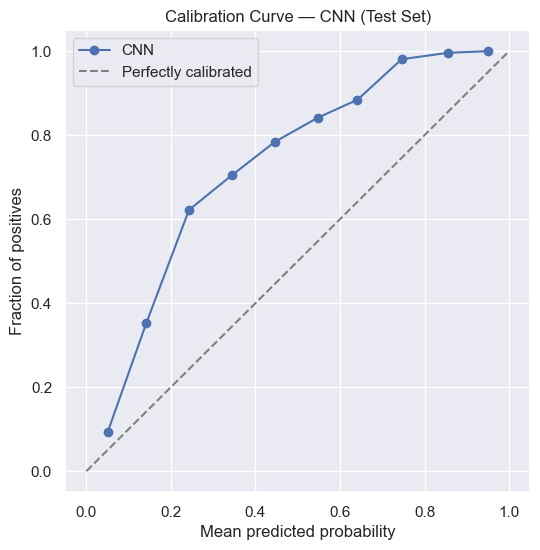

In [88]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

y_test_proba = cnn_model.predict(X_test_cnn).ravel()

test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)
print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print(f"Test PR-AUC: {test_pr_auc:.4f}")

prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, marker="o", label="CNN")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve — CNN (Test Set)")
ax.legend()
plt.show()

*End of Part 6 — cnn_model.ipynb (Edward Cho).*

---

## Part 7 — Subgroup Performance Evaluation

> **Contributor: Akim Jordan Williams** (`akim_williams@berkeley.edu`)
>
> **Inputs:** `X_train.csv`, `X_test.csv`, `Y_train.csv`, `Y_test.csv` (Part 2), `processed_data_test.csv` (Part 1, for raw `lead_time`) · **Outputs:** per-subgroup ROC-AUC, PR-AUC, precision, recall, and F1 for the final Random Forest on the held-out test set


### Hotel Cancellation — Subgroup Evaluation

We evaluate the final Random Forest (Part 5: `n_estimators=100`, `max_depth=None`, trained without `deposit_type_Non Refund`) across five booking-time partitions: hotel type, customer type, distribution channel, repeat vs. first-time guest, and lead-time bucket. Ranking metrics are omitted for any subgroup with fewer than 50 bookings or a single class.

#### 1. Setup


In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
)

# PROCESSED_DIR is resolved once in Part 0


#### 2. Retrain Final Random Forest

Same train/validation carve-out and hyperparameters as Part 5, so the overall test scores match the headline model before we slice by subgroup.


In [90]:
X_train_full = pd.read_csv(f"{PROCESSED_DIR}/X_train.csv")
X_test = pd.read_csv(f"{PROCESSED_DIR}/X_test.csv")
Y_train_full = pd.read_csv(f"{PROCESSED_DIR}/Y_train.csv")["is_canceled"]
Y_test = pd.read_csv(f"{PROCESSED_DIR}/Y_test.csv")["is_canceled"]

X_train_mini, _, Y_train_mini, _ = train_test_split(
    X_train_full, Y_train_full, test_size=0.2, random_state=1234,
    stratify=Y_train_full)

leaky_col = "deposit_type_Non Refund"
X_train_rf = X_train_mini.drop(columns=[leaky_col])
X_test_rf = X_test.drop(columns=[leaky_col])

final_rf = RandomForestClassifier(
    n_estimators=100, n_jobs=-1, random_state=7, max_depth=None)
final_rf.fit(X_train_rf, Y_train_mini)

test_prob = final_rf.predict_proba(X_test_rf)[:, 1]
test_pred = final_rf.predict(X_test_rf)

print("X_train_full:", X_train_full.shape, "  X_test:", X_test.shape)
print("Overall test ROC-AUC:", round(roc_auc_score(Y_test, test_prob), 4))
print("Overall test PR-AUC:", round(average_precision_score(Y_test, test_prob), 4))


X_train_full: (95368, 42)   X_test: (23840, 42)
Overall test ROC-AUC: 0.9496
Overall test PR-AUC: 0.9294


#### 3. Reconstruct Subgroup Labels

Hotel type, customer type, distribution channel, and guest status are recovered from the encoded `X_test` columns. Lead-time buckets use raw `lead_time` from `processed_data_test.csv`, aligned to the same NaN-filtered rows as `X_test`.


In [91]:
def from_onehot(frame, prefix, baseline):
    s = pd.Series(baseline, index=frame.index)
    for c in [c for c in frame.columns if c.startswith(prefix)]:
        s = s.mask(frame[c] == 1, c[len(prefix):])
    return s

test_raw = pd.read_csv(f"{PROCESSED_DIR}/processed_data_test.csv")
x_raw = test_raw.drop(columns=["is_canceled", "lead_time", "adr"])
y_raw = test_raw[["is_canceled"]]
mask = x_raw.notna().all(axis=1) & y_raw.notna().all(axis=1)
lead_time = test_raw.loc[mask, "lead_time"].reset_index(drop=True)
assert len(lead_time) == len(X_test)

groups = pd.DataFrame({
    "hotel": X_test["hotel"].map({1: "City Hotel", 0: "Resort Hotel"}),
    "customer_type": from_onehot(X_test, "customer_type_", "Contract"),
    "distribution_channel": from_onehot(
        X_test, "distribution_channel_", "Corporate"),
    "guest_status": X_test["is_repeated_guest"].map(
        {0: "First-time", 1: "Repeat"}),
    "lead_time_bucket": pd.cut(
        lead_time, bins=[-1, 7, 30, 90, np.inf],
        labels=["0-7", "8-30", "31-90", "90+"]).astype(str),
})

for col in groups.columns:
    print(f"--- {col} ---")
    print(groups[col].value_counts().to_string())
    print()


--- hotel ---
hotel
City Hotel      15729
Resort Hotel     8111

--- customer_type ---
customer_type
Transient          17850
Transient-Party     5028
Contract             836
Group                126

--- distribution_channel ---
distribution_channel
TA/TO        19489
Direct        2926
Corporate     1386
GDS             38
Undefined        1

--- guest_status ---
guest_status
First-time    23107
Repeat          733

--- lead_time_bucket ---
lead_time_bucket
90+      10214
31-90     5887
0-7       3896
8-30      3843



#### 4. Subgroup Metrics

For each level we report sample size, empirical cancel rate, ROC-AUC, PR-AUC, and hard-label precision / recall / F1 at the 0.5 threshold.


In [92]:
def subgroup_metrics(y_true, y_prob, y_pred, min_n=50):
    n = int(len(y_true))
    cancel_rate = float(y_true.mean()) if n else np.nan
    if n < min_n or y_true.nunique() < 2:
        return {"n": n, "cancel_rate": cancel_rate,
                "roc_auc": np.nan, "pr_auc": np.nan,
                "precision": np.nan, "recall": np.nan, "f1": np.nan}
    return {
        "n": n,
        "cancel_rate": cancel_rate,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

overall = subgroup_metrics(Y_test, test_prob, test_pred, min_n=1)
rows = [{"subgroup": "Overall", "level": "All test", **overall}]

for col in groups.columns:
    for level, idx in groups.groupby(col, observed=True).groups.items():
        m = subgroup_metrics(Y_test.loc[idx], test_prob[idx], test_pred[idx])
        rows.append({"subgroup": col, "level": str(level), **m})

subgroup_results = pd.DataFrame(rows)
for c in ["cancel_rate", "roc_auc", "pr_auc", "precision", "recall", "f1"]:
    subgroup_results[c] = subgroup_results[c].round(4)

subgroup_results


,subgroup,level,n,cancel_rate,roc_auc,pr_auc,precision,recall,f1
0,Overall,All test,23840,0.3708,0.9496,0.9294,0.8754,0.7918,0.8315
1,hotel,City Hotel,15729,0.4240,0.9461,0.9390,0.8901,0.8000,0.8426
2,hotel,Resort Hotel,8111,0.2675,0.9530,0.8948,0.8316,0.7668,0.7979
3,customer_type,Contract,836,0.3026,0.9957,0.9914,0.9748,0.9170,0.9450
4,customer_type,Group,126,0.1111,0.9962,0.9707,1.0000,0.7143,0.8333
5,customer_type,Transient,17850,0.4082,0.9336,0.9192,0.8617,0.7767,0.8170
6,customer_type,Transient-Party,5028,0.2558,0.9784,0.9579,0.9305,0.8538,0.8905
7,distribution_channel,Corporate,1386,0.2100,0.9637,0.9209,0.9157,0.7835,0.8444
8,distribution_channel,Direct,2926,0.1671,0.8927,0.7376,0.8412,0.4765,0.6084
9,distribution_channel,GDS,38,0.1842,NaN,NaN,NaN,NaN,NaN


#### 5. Visualize Subgroup PR-AUC and Recall

Dashed line is overall test PR-AUC. Sparse levels (`distribution_channel = Undefined`, `customer_type = Group`) are omitted when ranking metrics are undefined.


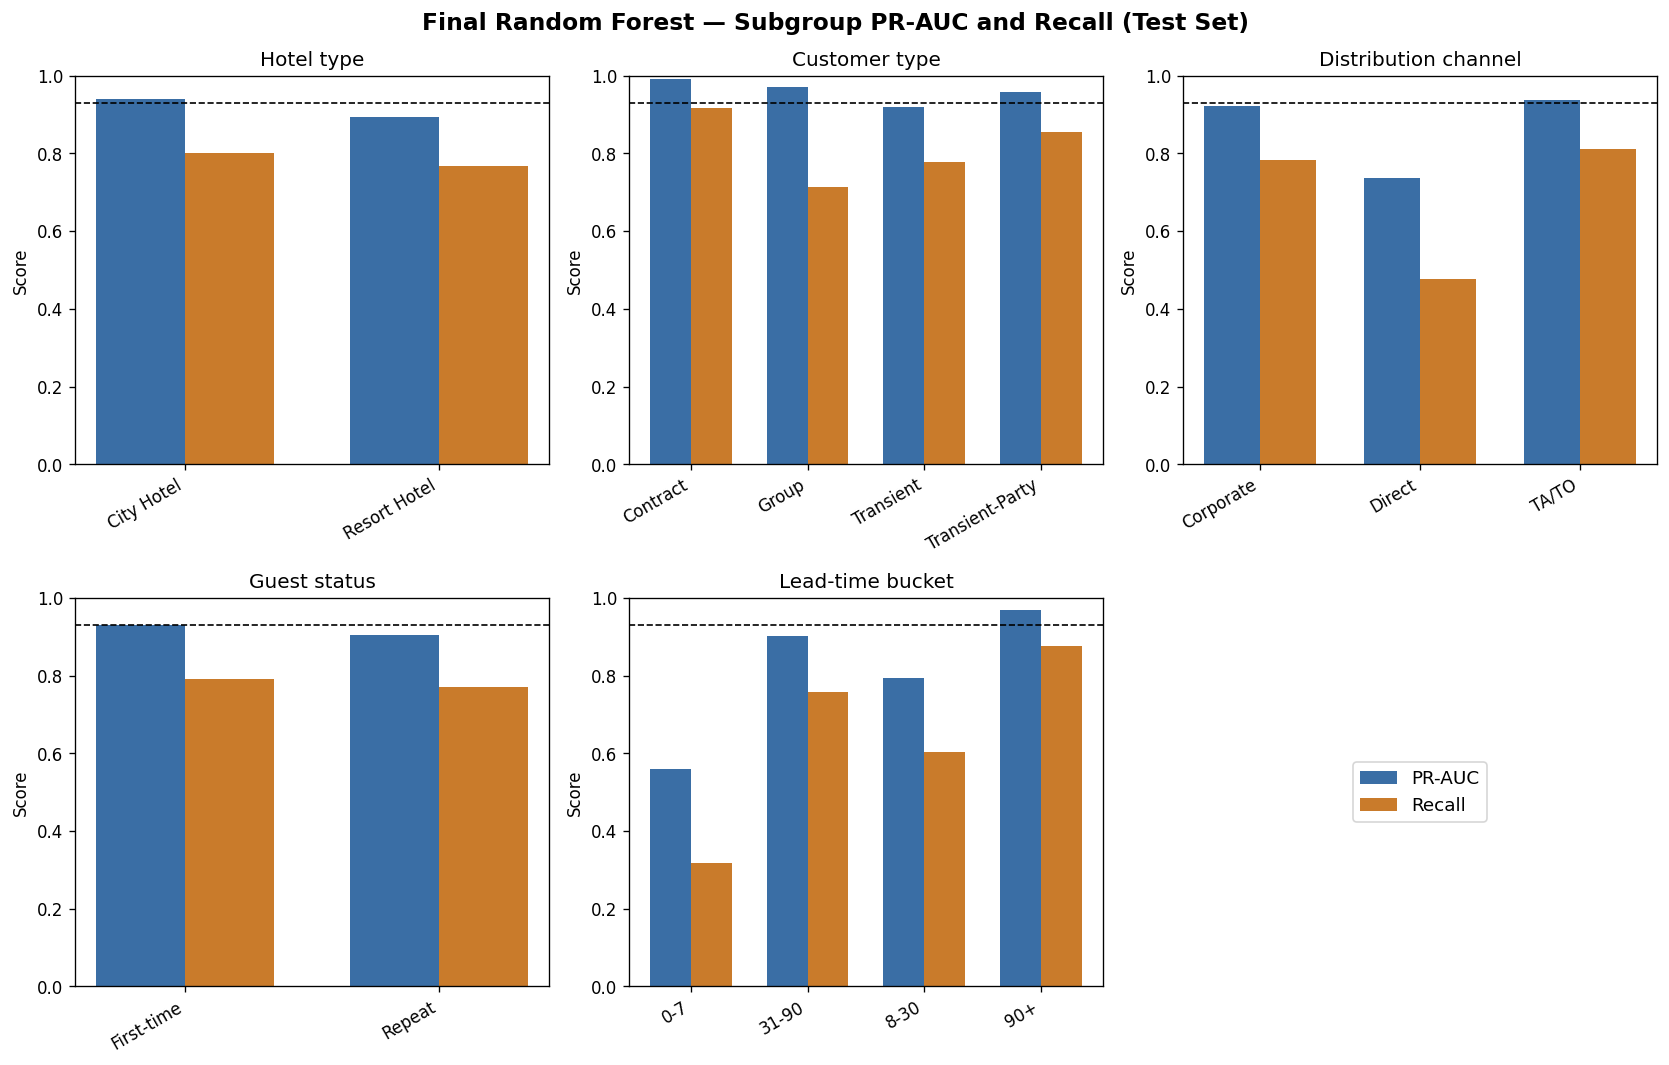

In [93]:
plot_cols = [
    ("hotel", "Hotel type"),
    ("customer_type", "Customer type"),
    ("distribution_channel", "Distribution channel"),
    ("guest_status", "Guest status"),
    ("lead_time_bucket", "Lead-time bucket"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

for ax, (col, title) in zip(axes, plot_cols):
    sub = subgroup_results[subgroup_results["subgroup"] == col].dropna(subset=["pr_auc"])
    x = np.arange(len(sub))
    w = 0.35
    ax.bar(x - w / 2, sub["pr_auc"], width=w, label="PR-AUC", color="#3A6EA5")
    ax.bar(x + w / 2, sub["recall"], width=w, label="Recall", color="#C97B2B")
    ax.axhline(overall["pr_auc"], color="black", linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["level"], rotation=30, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_ylabel("Score")

axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels + ["Overall PR-AUC"], loc="center", fontsize=11)
fig.suptitle("Final Random Forest — Subgroup PR-AUC and Recall (Test Set)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


#### 6. Summary

| Partition | Strongest PR-AUC level | Weakest usable PR-AUC level |
|---|---|---|
| Hotel type | City Hotel (0.939) | Resort Hotel (0.895) |
| Guest status | First-time (0.930) | Repeat (0.905) |
| Lead-time bucket | 90+ days (0.969) | 0–7 days (0.560) |
| Distribution channel | TA/TO (0.938) | Direct (0.738) |

Performance is strongest where cancel rates are highest (city hotels, TA/TO bookings, long lead times) and weaker on low-base-rate groups (resort hotels, repeat guests, last-minute bookings). That pattern is expected under PR-AUC: the ranking task is harder when positives are rare. The clearest operational gaps are Direct-channel recall (47.6%) and 0–7 day lead-time recall (31.8%), a hotel whose book of business is mostly short-lead direct bookings should not treat the aggregate 0.929 test PR-AUC as representative. Ranking metrics are left blank for `GDS` (n=38) and `Undefined` (n=1).


*End of Part 7 — subgroup evaluation (Akim Jordan Williams).*